# Computational Aspects of Ramanujan Summation

This notebook demonstrates the computation of various infinite series sums using tail approximations. Each example is run in its own cell so you can capture the output (both numerical and plots) for your Thesis.

In [1]:
# Install and update required packages
import Pkg
Pkg.activate(".")
Pkg.instantiate()

# Add/update required packages
Pkg.add("SymPy")
Pkg.add("Plots")
Pkg.add("Printf")
Pkg.add("SpecialFunctions")
Pkg.update()

  Activating project at `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
    Updating registry at `~/.julia/registries/General.toml`

## Module Definition: Analytictail

The following cell defines the module `Analytictail` which contains all functions needed for computing the infinite series sums using Euler–Maclaurin (for non‐alternating series) and Euler–Boole (for alternating series) tail approximations. Note that we export the symbols `run_example` and `x_` so they can be used directly from the Main module.

In [2]:
module Analytictail

using SymPy
using Plots
using Printf
using SpecialFunctions  # For coth, etc.

export run_example, sum_infinite_series, plot_error_vs_m, x_

##########################################################
# 1) Setup
##########################################################
setprecision(256)  # Very high precision for demonstration
gr()

# Partial-sum cutoffs
const Kset = [1, 2, 3, 4]
# Max correction terms
const m_max = 30

# We'll store Bernoulli / Euler polynomials in caches
const bernoulliCache = Dict{Int, Vector{Rational{BigInt}}}()
const eulerPolyCache = Dict{Tuple{Int, Float64}, Dict{Int, Float64}}()

##########################################################
# 2) Bernoulli numbers (caching)
##########################################################
function BernoulliListCached(n::Int)::Vector{Rational{BigInt}}
    if haskey(bernoulliCache, n)
        return bernoulliCache[n]
    end
    A = Vector{Rational{BigInt}}(undef, n+1)
    B = similar(A)
    for mm in 0:n
        A[mm+1] = 1 // (mm+1)
        for j in mm:-1:1
            A[j] = j*(A[j]-A[j+1])
        end
        B[mm+1] = A[1]
    end
    bernoulliCache[n] = B
    return B
end

##########################################################
# 3) Euler polynomials (for Euler–Boole)
##########################################################
function euler_polynomials_cached(max_n::Int, x_val::Float64)::Dict{Int, Float64}
    key = (max_n, x_val)
    if haskey(eulerPolyCache, key)
        return eulerPolyCache[key]
    end

    t = SymPy.symbols("t")
    expr = (2*SymPy.exp(x_val*t)) / (SymPy.exp(t)+1)
    out = Dict{Int, Float64}()
    for n in 0:max_n
        try
            ser = expr.series(t, 0, n+1).expand()
            coeff_n = factorial(big(n))*ser.coeff(t,n)
            out[n] = float(coeff_n)
        catch
            @warn "Failed Euler poly E_$n($x_val)"
            out[n] = 0.0
        end
    end
    eulerPolyCache[key] = out
    return out
end

##########################################################
# 4) Utility: safe_real_float
##########################################################
function safe_real_float(expr)::Float64
    try
        val = expr.evalf()
        return float(SymPy.real(val))
    catch
        return NaN
    end
end

##########################################################
# 5) Euler–Boole tail approximation (ALTERNATING)
##########################################################
function euler_boole_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    f1 = safe_real_float(f.subs(x_, 1))

    e_dict = euler_polynomials_cached(m, 1.0)
    sum_corr = 0.0
    for j in 1:m
        d_expr = diff(f, x_, j).subs(x_, 1)
        d_val  = safe_real_float(d_expr)
        e_j    = e_dict[j]
        sum_corr += (e_j / factorial(big(j))) * d_val
    end
    return 0.5*f1 + sum_corr
end

##########################################################
# 6) Euler–Maclaurin tail approximation (NON-ALTERNATING)
##########################################################
function euler_maclaurin_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    
    integral_sym = try
        SymPy.integrate(f, (x_, 1, SymPy.oo))
    catch
        nothing
    end

    if integral_sym === nothing || integral_sym == SymPy.oo || integral_sym == -SymPy.oo
        #@warn "Analytical integration failed or diverged; setting integral to 0.0."
        integral_val = 0.0
    else
        integral_val = safe_real_float(integral_sym)
    end

    half_term = 0.5 * safe_real_float(f.subs(x_, 1))
    
    Blist = BernoulliListCached(2*m)
    sum_corr = 0.0
    for j in 1:m
        dorder = 2*j - 1
        dexpr  = diff(f, x_, dorder).subs(x_, 1)
        dval   = safe_real_float(dexpr)
        b_2j   = float(Blist[2*j+1])
        denom  = factorial(big(2*j))
        sum_corr += (b_2j / denom) * dval
    end

    return integral_val + half_term - sum_corr
end

##########################################################
# 7) sum_infinite_series = partial sum + tail
##########################################################
function sum_infinite_series(f::Sym, k::Int, m::Int, alt::Bool)::Float64
    local x_ = SymPy.symbols("x")

    S_k = 0.0
    for n in 1:k
        S_k += safe_real_float(f.subs(x_, n))
    end

    f_tail = f.subs(x_, x_ + k)

    if alt
        return S_k + euler_boole_infinite_tail(f_tail, m)
    else
        return S_k + euler_maclaurin_infinite_tail(f_tail, m)
    end
end

##########################################################
# 8) plot_error_vs_m
##########################################################
function plot_error_vs_m(f::Sym, desc::String, known_val::Float64, alt::Bool)
    p = plot(
        title = desc * " : log10(|error|) vs. m",
        xlabel = "m (derivative expansions)",
        ylabel = "log10(|error|)",
        legend = :topright
    )

    for k in Kset
        local logerrs = Float64[]
        println("\n$desc => alt=$alt, k=$k => exact=$known_val")
        # Print Markdown table header
        println("| m | Approx | Error |")
        println("|---|---|---|")
        for mm in 1:m_max
            approx = sum_infinite_series(f, k, mm, alt)
            err = abs(approx - known_val)
            # Print each row in Markdown table format
            @printf("| %2d | %.16e | %.16e |\n", mm, approx, err)
            push!(logerrs, log10(max(err, 1e-300)))
        end
        plot!(p, 1:m_max, logerrs, label="k=$k", linewidth=2)
    end

    # Create the 'plots' directory if it doesn't exist
    if !isdir("plots")
        mkdir("plots")
    end

    # Sanitize the description for a valid filename (replace invalid characters)
    safe_desc = replace(desc, r"[^a-zA-Z0-9\-_\.]" => "")
    # Save the plot to the 'plots' folder
    savefig(p, joinpath("plots", "$(safe_desc).png"))

    display(p)
end

function run_example(f::Sym, desc::String, known_val::Float64, alt::Bool)
    println("\n=== run_example: $desc")
    plot_error_vs_m(f, desc, known_val, alt)
end


# Export x_ for use in Main
const x_ = SymPy.symbols("x")

end # module

Main.Analytictail

In [3]:
# Import the module into Main
using .Analytictail

In [4]:
# Import SymPy into Main so that `Sym` is defined
using SymPy

### Example 1: Euler Macheroni: sum(1/n)


=== run_example: Euler Macheroni: sum(1/n)

Euler Macheroni: sum(1/n) => alt=false, k=1 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.2708333333333333e+00 | 6.9362333333333326e-01 |
|  2 | 1.2703125000000000e+00 | 6.9310249999999995e-01 |
|  3 | 1.2703745039682539e+00 | 6.9316450396825391e-01 |
|  4 | 1.2703582279265873e+00 | 6.9314822792658726e-01 |
|  5 | 1.2703656261273448e+00 | 6.9315562612734483e-01 |
|  6 | 1.2703604765189238e+00 | 6.9315047651892381e-01 |
|  7 | 1.2703655627819446e+00 | 6.9315556278194457e-01 |
|  8 | 1.2703587991740968e+00 | 6.9314879917409677e-01 |
|  9 | 1.2703704490853296e+00 | 6.9316044908532959e-01 |
| 10 | 1.2703452184753203e+00 | 6.9313521847532034e-01 |
| 11 | 1.2704123238031477e+00 | 6.9320232380314772e-01 |
| 12 | 1.2701972994185060e+00 | 6.9298729941850601e-01 |
| 13 | 1.2710142940756253e+00 | 6.9380429407562527e-01 |
| 14 | 1.2673823713841215e+00 | 6.9017237138412146e-01 |
| 15 | 1.2860578996614740e+00 | 7.0884789966147399e-01 |
| 

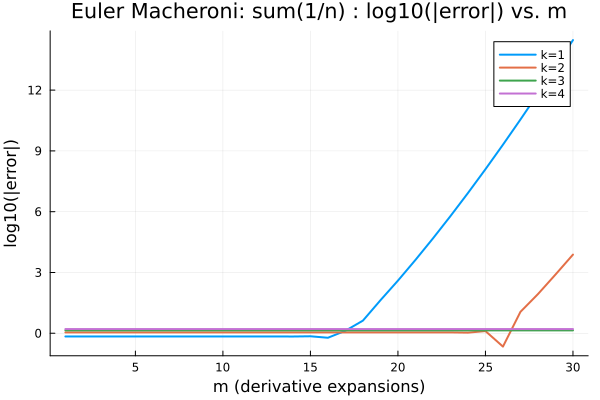

In [5]:
run_example(1/x_, "Euler Macheroni: sum(1/n)", 0.57721, false)

=== run_example: Euler Macheroni: sum(1/n)

![Plot for Euler Macheroni sum(1/n)](plots/EulerMacheronisum1n.png)

Euler Macheroni: sum(1/n) => alt=false, k=1 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.2708333333333333e+00 | 6.9362333333333326e-01 |
|  2 | 1.2703125000000000e+00 | 6.9310249999999995e-01 |
|  3 | 1.2703745039682539e+00 | 6.9316450396825391e-01 |
|  4 | 1.2703582279265873e+00 | 6.9314822792658726e-01 |
|  5 | 1.2703656261273448e+00 | 6.9315562612734483e-01 |
|  6 | 1.2703604765189238e+00 | 6.9315047651892381e-01 |
|  7 | 1.2703655627819446e+00 | 6.9315556278194457e-01 |
|  8 | 1.2703587991740968e+00 | 6.9314879917409677e-01 |
|  9 | 1.2703704490853296e+00 | 6.9316044908532959e-01 |
| 10 | 1.2703452184753203e+00 | 6.9313521847532034e-01 |
| 11 | 1.2704123238031477e+00 | 6.9320232380314772e-01 |
| 12 | 1.2701972994185060e+00 | 6.9298729941850601e-01 |
| 13 | 1.2710142940756253e+00 | 6.9380429407562527e-01 |
| 14 | 1.2673823713841215e+00 | 6.9017237138412146e-01 |
| 15 | 1.2860578996614740e+00 | 7.0884789966147399e-01 |
| 16 | 1.1760722268574988e+00 | 5.9886222685749879e-01 |
| 17 | 1.9115682111741084e+00 | 1.3343582111741084e+00 |
| 18 | -3.6309552384103512e+00 | 4.2081652384103512e+00 |
| 19 | 4.3120166531165502e+01 | 4.2542956531165501e+01 |
| 20 | -3.9563325031472027e+02 | 3.9621046031472025e+02 |
| 21 | 4.1610058406815515e+03 | 4.1604286306815511e+03 |
| 22 | -4.7951583123810997e+04 | 4.7952160333811000e+04 |
| 23 | 6.0546192994910164e+05 | 6.0546135273910163e+05 |
| 24 | -8.3404387734500226e+06 | 8.3404393506600223e+06 |
| 25 | 1.2490172068478714e+08 | 1.2490172010757715e+08 |
| 26 | -2.0267011501772575e+09 | 2.0267011507544675e+09 |
| 27 | 3.5524306919110771e+10 | 3.5524306918533562e+10 |
| 28 | -6.7072546658672815e+11 | 6.7072546658730542e+11 |
| 29 | 1.3605108101662811e+13 | 1.3605108101662232e+13 |
| 30 | -2.9575317824184738e+14 | 2.9575317824184794e+14 |

Euler Macheroni: sum(1/n) => alt=false, k=2 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.6759259259259260e+00 | 1.0987159259259260e+00 |
|  2 | 1.6758230452674896e+00 | 1.0986130452674896e+00 |
|  3 | 1.6758284886885710e+00 | 1.0986184886885710e+00 |
|  4 | 1.6758278536227782e+00 | 1.0986178536227782e+00 |
|  5 | 1.6758279819188979e+00 | 1.0986179819188979e+00 |
|  6 | 1.6758279422290809e+00 | 1.0986179422290809e+00 |
|  7 | 1.6758279596520107e+00 | 1.0986179596520107e+00 |
|  8 | 1.6758279493548314e+00 | 1.0986179493548314e+00 |
|  9 | 1.6758279572376213e+00 | 1.0986179572376213e+00 |
| 10 | 1.6758279496500537e+00 | 1.0986179496500537e+00 |
| 11 | 1.6758279586191629e+00 | 1.0986179586191629e+00 |
| 12 | 1.6758279458460279e+00 | 1.0986179458460279e+00 |
| 13 | 1.6758279674158461e+00 | 1.0986179674158461e+00 |
| 14 | 1.6758279247989964e+00 | 1.0986179247989964e+00 |
| 15 | 1.6758280221936515e+00 | 1.0986180221936515e+00 |
| 16 | 1.6758277672666568e+00 | 1.0986177672666568e+00 |
| 17 | 1.6758285249321319e+00 | 1.0986185249321319e+00 |
| 18 | 1.6758259873376971e+00 | 1.0986159873376971e+00 |
| 19 | 1.6758355004843519e+00 | 1.0986255004843519e+00 |
| 20 | 1.6757958206226899e+00 | 1.0985858206226899e+00 |
| 21 | 1.6759789726588727e+00 | 1.0987689726588727e+00 |
| 22 | 1.6750480207407294e+00 | 1.0978380207407294e+00 |
| 23 | 1.6802359040050503e+00 | 1.1030259040050503e+00 |
| 24 | 1.6486681532690872e+00 | 1.0714581532690872e+00 |
| 25 | 1.8576356354093659e+00 | 1.2804256354093659e+00 |
| 26 | 3.5789332389017470e-01 | 2.1931667610982530e-01 |
| 27 | 1.1990943766707534e+01 | 1.1413733766707534e+01 |
| 28 | -8.5249697552867772e+01 | 8.5826907552867766e+01 |
| 29 | 7.8834190550915798e+02 | 7.8776469550915795e+02 |
| 30 | -7.6253423500182171e+03 | 7.6259195600182175e+03 |

Euler Macheroni: sum(1/n) => alt=false, k=3 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.9635416666666665e+00 | 1.3863316666666665e+00 |
|  2 | 1.9635091145833332e+00 | 1.3862991145833332e+00 |
|  3 | 1.9635100833953372e+00 | 1.3863000833953372e+00 |
|  4 | 1.9635100198170494e+00 | 1.3863000198170494e+00 |
|  5 | 1.9635100270418548e+00 | 1.3863000270418548e+00 |
|  6 | 1.9635100257846263e+00 | 1.3863000257846263e+00 |
|  7 | 1.9635100260950671e+00 | 1.3863000260950671e+00 |
|  8 | 1.9635100259918628e+00 | 1.3863000259918627e+00 |
|  9 | 1.9635100260363036e+00 | 1.3863000260363036e+00 |
| 10 | 1.9635100260122418e+00 | 1.3863000260122418e+00 |
| 11 | 1.9635100260282410e+00 | 1.3863000260282410e+00 |
| 12 | 1.9635100260154246e+00 | 1.3863000260154246e+00 |
| 13 | 1.9635100260275986e+00 | 1.3863000260275986e+00 |
| 14 | 1.9635100260140688e+00 | 1.3863000260140688e+00 |
| 15 | 1.9635100260314617e+00 | 1.3863000260314617e+00 |
| 16 | 1.9635100260058536e+00 | 1.3863000260058536e+00 |
| 17 | 1.9635100260486651e+00 | 1.3863000260486651e+00 |
| 18 | 1.9635100259680107e+00 | 1.3863000259680107e+00 |
| 19 | 1.9635100261380902e+00 | 1.3863000261380902e+00 |
| 20 | 1.9635100257390463e+00 | 1.3863000257390463e+00 |
| 21 | 1.9635100267751062e+00 | 1.3863000267751062e+00 |
| 22 | 1.9635100238128484e+00 | 1.3863000238128484e+00 |
| 23 | 1.9635100330984130e+00 | 1.3863000330984130e+00 |
| 24 | 1.9635100013161892e+00 | 1.3863000013161892e+00 |
| 25 | 1.9635101196589999e+00 | 1.3863001196589999e+00 |
| 26 | 1.9635096419071905e+00 | 1.3862996419071905e+00 |
| 27 | 1.9635117264068782e+00 | 1.3863017264068782e+00 |
| 28 | 1.9635019252223822e+00 | 1.3862919252223822e+00 |
| 29 | 1.9635514544696422e+00 | 1.3863414544696422e+00 |
| 30 | 1.9632831289287380e+00 | 1.3860731289287380e+00 |

Euler Macheroni: sum(1/n) => alt=false, k=4 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 2.1866666666666665e+00 | 1.6094566666666665e+00 |
|  2 | 2.1866533333333331e+00 | 1.6094433333333331e+00 |
|  3 | 2.1866535873015871e+00 | 1.6094435873015871e+00 |
|  4 | 2.1866535766349204e+00 | 1.6094435766349204e+00 |
|  5 | 2.1866535774106781e+00 | 1.6094435774106781e+00 |
|  6 | 2.1866535773242819e+00 | 1.6094435773242819e+00 |
|  7 | 2.1866535773379350e+00 | 1.6094435773379350e+00 |
|  8 | 2.1866535773350302e+00 | 1.6094435773350302e+00 |
|  9 | 2.1866535773358309e+00 | 1.6094435773358309e+00 |
| 10 | 2.1866535773355533e+00 | 1.6094435773355533e+00 |
| 11 | 2.1866535773356715e+00 | 1.6094435773356714e+00 |
| 12 | 2.1866535773356111e+00 | 1.6094435773356111e+00 |
| 13 | 2.1866535773356479e+00 | 1.6094435773356479e+00 |
| 14 | 2.1866535773356217e+00 | 1.6094435773356217e+00 |
| 15 | 2.1866535773356430e+00 | 1.6094435773356430e+00 |
| 16 | 2.1866535773356226e+00 | 1.6094435773356226e+00 |
| 17 | 2.1866535773356444e+00 | 1.6094435773356444e+00 |
| 18 | 2.1866535773356182e+00 | 1.6094435773356182e+00 |
| 19 | 2.1866535773356537e+00 | 1.6094435773356537e+00 |
| 20 | 2.1866535773356004e+00 | 1.6094435773356004e+00 |
| 21 | 2.1866535773356888e+00 | 1.6094435773356888e+00 |
| 22 | 2.1866535773355276e+00 | 1.6094435773355276e+00 |
| 23 | 2.1866535773358509e+00 | 1.6094435773358509e+00 |
| 24 | 2.1866535773351421e+00 | 1.6094435773351421e+00 |
| 25 | 2.1866535773368314e+00 | 1.6094435773368314e+00 |
| 26 | 2.1866535773324673e+00 | 1.6094435773324673e+00 |
| 27 | 2.1866535773446532e+00 | 1.6094435773446532e+00 |
| 28 | 2.1866535773079829e+00 | 1.6094435773079829e+00 |
| 29 | 2.1866535774265818e+00 | 1.6094435774265818e+00 |
| 30 | 2.1866535770153739e+00 | 1.6094435770153739e+00 |

### Example 2: Basel: sum(1/n²) = π²/6

In [ ]:
run_example(1/x_^2, "Basel: sum(1/n²) = π²/6", float(pi^2/6), false)

=== run_example: Basel: sum(1/n²) = π²/6

Basel: sum(1/n²) = π²/6 => alt=false, k=1 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6458333333333335e+00 | 8.9926648510707530e-04 |
|  2 | 1.6447916666666667e+00 | 1.4240018155975420e-04 |
|  3 | 1.6449776785714287e+00 | 4.3611723202330310e-05 |
|  4 | 1.6449125744047619e+00 | 2.1492443464499189e-05 |
|  5 | 1.6449495654085498e+00 | 1.5498560323345956e-05 |
|  6 | 1.6449186677580232e+00 | 1.5399090203205290e-05 |
|  7 | 1.6449542715991692e+00 | 2.0204750942776073e-05 |
|  8 | 1.6449001627363855e+00 | 3.3904111840898921e-05 |
|  9 | 1.6450050119374828e+00 | 7.0945089256424509e-05 |
| 10 | 1.6447527058373890e+00 | 1.8136101083743306e-04 |
| 11 | 1.6454908644434898e+00 | 5.5679759526339190e-04 |
| 12 | 1.6429105718277914e+00 | 2.0234950204349733e-03 |
| 13 | 1.6535315023703399e+00 | 8.5974355221134502e-03 |
| 14 | 1.6026845846892863e+00 | 4.2249482158940088e-02 |
| 15 | 1.8828175088495742e+00 | 2.3788344200134781e-01 |
| 16 | 1.2304674398597193e-01 | 1.5218873228622545e+00 |
| 17 | 1.2626478477368334e+01 | 1.0981544410520108e+01 |
| 18 | -8.7138943615151916e+01 | 8.8783877682000139e+01 |
| 19 | 8.0113237000678930e+02 | 7.9948743593994107e+02 |
| 20 | -7.9739359669109253e+03 | 7.9755809009777731e+03 |
| 21 | 8.7715484944010779e+04 | 8.7713840009943931e+04 |
| 22 | -1.0587614722748254e+06 | 1.0587631172088922e+06 |
| 23 | 1.3969749328402167e+07 | 1.3969747683468100e+07 |
| 24 | -2.0073186755317682e+08 | 2.0073186919811088e+08 |
| 25 | 3.1303221189027524e+09 | 3.1303221172578182e+09 |
| 26 | -5.2811352523510406e+10 | 5.2811352525155342e+10 |
| 27 | 9.6106586534726636e+11 | 9.6106586534562146e+11 |
| 28 | -1.8813927792816223e+13 | 1.8813927792817867e+13 |
| 29 | 3.9518524568642038e+14 | 3.9518524568641875e+14 |
| 30 | -8.8855633446188850e+15 | 8.8855633446188870e+15 |

Basel: sum(1/n²) = π²/6 => alt=false, k=2 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6450617283950617e+00 | 1.2766154683530040e-04 |
|  2 | 1.6449245541838133e+00 | 9.5126644130694160e-06 |
|  3 | 1.6449354410259760e+00 | 1.3741777495912544e-06 |
|  4 | 1.6449337475171952e+00 | 3.1933103117331996e-07 |
|  5 | 1.6449341751709277e+00 | 1.0832270125327170e-07 |
|  6 | 1.6449340164116593e+00 | 5.0436567144984679e-08 |
|  7 | 1.6449340977186653e+00 | 3.0870438871843930e-08 |
|  8 | 1.6449340428003756e+00 | 2.4047850821773409e-08 |
|  9 | 1.6449340900971152e+00 | 2.3248888814109137e-08 |
| 10 | 1.6449340395133316e+00 | 2.7334894792119258e-08 |
| 11 | 1.6449341052867978e+00 | 3.8438571436927305e-08 |
| 12 | 1.6449340031017192e+00 | 6.3746507183992662e-08 |
| 13 | 1.6449341900401420e+00 | 1.2319191555754117e-07 |
| 14 | 1.6449337922828788e+00 | 2.7456534756886697e-07 |
| 15 | 1.6449347662294298e+00 | 6.9938120339507748e-07 |
| 16 | 1.6449320470081539e+00 | 2.0198400725313093e-06 |
| 17 | 1.6449406338835384e+00 | 6.5670353119884339e-06 |
| 18 | 1.6449101827503185e+00 | 2.3884097907878044e-05 |
| 19 | 1.6450306826079477e+00 | 9.6615759721307981e-05 |
| 20 | 1.6445016177857874e+00 | 4.3244906243899983e-04 |
| 21 | 1.6470657462923488e+00 | 2.1316794441224030e-03 |
| 22 | 1.6334117848262470e+00 | 1.1522282021979358e-02 |
| 23 | 1.7129593282125002e+00 | 6.8025261364273781e-02 |
| 24 | 1.2078753164370888e+00 | 4.3705875041113762e-01 |
| 25 | 4.6906666854417356e+00 | 3.0457326185935090e+00 |
| 26 | -2.1304866714224243e+01 | 2.2949800781072469e+01 |
| 27 | 1.8809004125648823e+02 | 1.8644510718964000e+02 |
| 28 | -1.6270685967089173e+03 | 1.6287135307757655e+03 |
| 29 | 1.5262369062490247e+04 | 1.5260724128423399e+04 |
| 30 | -1.5301131604805726e+05 | 1.5301296098212412e+05 |

Basel: sum(1/n²) = π²/6 => alt=false, k=3 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6449652777777779e+00 | 3.1210929551495070e-05 |
|  2 | 1.6449327256944444e+00 | 1.3411537820307018e-06 |
|  3 | 1.6449341789124505e+00 | 1.1206422412257666e-07 |
|  4 | 1.6449340517558748e+00 | 1.5092351590695330e-08 |
|  5 | 1.6449340698178885e+00 | 2.9696620718056010e-09 |
|  6 | 1.6449340660462026e+00 | 8.0202378072158353e-10 |
|  7 | 1.6449340671327457e+00 | 2.8451929701134304e-10 |
|  8 | 1.6449340667199277e+00 | 1.2829870499331264e-10 |
|  9 | 1.6449340669199117e+00 | 7.1685324343206958e-11 |
| 10 | 1.6449340667996029e+00 | 4.8623549631088281e-11 |
| 11 | 1.6449340668875982e+00 | 3.9371839122281926e-11 |
| 12 | 1.6449340668106995e+00 | 3.7526870499959841e-11 |
| 13 | 1.6449340668898316e+00 | 4.1605163758617891e-11 |
| 14 | 1.6449340667951218e+00 | 5.3104631803080338e-11 |
| 15 | 1.6449340669255688e+00 | 7.7342354742881980e-11 |
| 16 | 1.6449340667207046e+00 | 1.2752177092067996e-10 |
| 17 | 1.6449340670846024e+00 | 2.3637602986070760e-10 |
| 18 | 1.6449340663587133e+00 | 4.8951309672418120e-10 |
| 19 | 1.6449340679744695e+00 | 1.1262430987812877e-09 |
| 20 | 1.6449340639840304e+00 | 2.8641959914921244e-09 |
| 21 | 1.6449340748626580e+00 | 8.0144315628416507e-09 |
| 22 | 1.6449340422778231e+00 | 2.4570403267532015e-08 |
| 23 | 1.6449341490618150e+00 | 8.2213588603607946e-08 |
| 24 | 1.6449337676751292e+00 | 2.9917309718463514e-07 |
| 25 | 1.6449352469602623e+00 | 1.1801120358700956e-06 |
| 26 | 1.6449290361867397e+00 | 5.0306614867157151e-06 |
| 27 | 1.6449571769325253e+00 | 2.3110084298894051e-05 |
| 28 | 1.6448199603495808e+00 | 1.1410649864562750e-04 |
| 29 | 1.6455381344348503e+00 | 6.0406758662390203e-04 |
| 30 | 1.6415132513212900e+00 | 3.4208155269364049e-03 |

Basel: sum(1/n²) = π²/6 => alt=false, k=4 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6449444444444445e+00 | 1.0377596218136276e-05 |
|  2 | 1.6449337777777777e+00 | 2.8907044868908827e-07 |
|  3 | 1.6449340825396825e+00 | 1.5691456134447890e-08 |
|  4 | 1.6449340654730160e+00 | 1.3752103900088741e-09 |
|  5 | 1.6449340670245312e+00 | 1.7630474857810441e-10 |
|  6 | 1.6449340668171804e+00 | 3.1046054616012952e-11 |
|  7 | 1.6449340668554098e+00 | 7.1833650139296878e-12 |
|  8 | 1.6449340668461139e+00 | 2.1125323712567479e-12 |
|  9 | 1.6449340668489960e+00 | 7.6960660067015851e-13 |
| 10 | 1.6449340668478865e+00 | 3.3995029014022293e-13 |
| 11 | 1.6449340668484058e+00 | 1.7941204077942530e-13 |
| 12 | 1.6449340668481154e+00 | 1.1102230246251565e-13 |
| 13 | 1.6449340668483066e+00 | 8.0158102377936302e-14 |
| 14 | 1.6449340668481600e+00 | 6.6391336872584361e-14 |
| 15 | 1.6449340668482892e+00 | 6.2838623193783860e-14 |
| 16 | 1.6449340668481593e+00 | 6.7057470687359455e-14 |
| 17 | 1.6449340668483070e+00 | 8.0602191587786365e-14 |
| 18 | 1.6449340668481185e+00 | 1.0791367799356522e-13 |
| 19 | 1.6449340668483869e+00 | 1.6053824936079764e-13 |
| 20 | 1.6449340668479626e+00 | 2.6378899065093719e-13 |
| 21 | 1.6449340668487031e+00 | 4.7672976677404222e-13 |
| 22 | 1.6449340668472838e+00 | 9.4257934790675790e-13 |
| 23 | 1.6449340668502606e+00 | 2.0341506257182118e-12 |
| 24 | 1.6449340668434562e+00 | 4.7701842476044476e-12 |
| 25 | 1.6449340668603467e+00 | 1.2120304759832834e-11 |
| 26 | 1.6449340668149615e+00 | 3.3264946353028790e-11 |
| 27 | 1.6449340669465702e+00 | 9.8343777565901291e-11 |
| 28 | 1.6449340665358598e+00 | 3.1236657704880599e-10 |
| 29 | 1.6449340679116080e+00 | 1.0633816049931966e-09 |
| 30 | 1.6449340629771156e+00 | 3.8711107652744658e-09 |

### Example 3: Zeta(3): sum(1/n³) ≈ 1.20206

In [ ]:
run_example(1/x_^3, "Zeta(3): sum(1/n³) ≈ 1.20206", 1.202056903159594, false)

=== run_example: Zeta(3): sum(1/n³) ≈ 1.20206

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=1 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2031250000000000e+00 | 1.0680968404059854e-03 |
|  2 | 1.2018229166666667e+00 | 2.3398649292727391e-04 |
|  3 | 1.2021484375000000e+00 | 9.1534340405985404e-05 |
|  4 | 1.2020019531249999e+00 | 5.4950034594103414e-05 |
|  5 | 1.2021036783854167e+00 | 4.6775225822637267e-05 |
|  6 | 1.2020032610212055e+00 | 5.3642138388543259e-05 |
|  7 | 1.2021367754255023e+00 | 7.9872265908331741e-05 |
|  8 | 1.2019068127586727e+00 | 1.5009040092128778e-04 |
|  9 | 1.2024048464638846e+00 | 3.4794330429055442e-04 |
| 10 | 1.2010802394383913e+00 | 9.7666372120275291e-04 |
| 11 | 1.2053246514234708e+00 | 3.2677482638767685e-03 |
| 12 | 1.1891978225753559e+00 | 1.2859080584238125e-02 |
| 13 | 1.2608891037375582e+00 | 5.8832200577964233e-02 |
| 14 | 8.9224895054992082e-01 | 3.0980795260967320e-01 |
| 15 | 3.0632791127921517e+00 | 1.8612222096325577e+00 |
| 16 | -1.1454829697332567e+01 | 1.2656886600492161e+01 |
| 17 | 9.7950197969763096e+01 | 9.6748141066603495e+01 |
| 18 | -8.2487995638604934e+02 | 8.2608201328920893e+02 |
| 19 | 7.8357653514278772e+03 | 7.8345632945247180e+03 |
| 20 | -8.2108685101978699e+04 | 8.2109887158881858e+04 |
| 21 | 9.4655258969042951e+05 | 9.4655138763352635e+05 |
| 22 | -1.1951313179021476e+07 | 1.1951314381078379e+07 |
| 23 | 1.6463368872893319e+08 | 1.6463368752687627e+08 |
| 24 | -2.4654611180704093e+09 | 2.4654611192724662e+09 |
| 25 | 4.0005477209242691e+10 | 4.0005477208040634e+10 |
| 26 | -7.0122171180273169e+11 | 7.0122171180393372e+11 |
| 27 | 1.3239590033920449e+13 | 1.3239590033919248e+13 |
| 28 | -2.6855406959490925e+14 | 2.6855406959491044e+14 |
| 29 | 5.8379337392238310e+15 | 5.8379337392238300e+15 |
| 30 | -1.3569348226293210e+17 | 1.3569348226293210e+17 |

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=2 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2021604938271604e+00 | 1.0359066756637780e-04 |
|  2 | 1.2020461819844537e+00 | 1.0721175140337991e-05 |
|  3 | 1.2020588833003099e+00 | 1.9801407158404061e-06 |
|  4 | 1.2020563430371387e+00 | 5.6012245530645544e-07 |
|  5 | 1.2020571270689817e+00 | 2.2390938769767388e-07 |
|  6 | 1.2020567830905666e+00 | 1.2006902738725955e-07 |
|  7 | 1.2020569863580817e+00 | 8.3198487654811970e-08 |
|  8 | 1.2020568307562611e+00 | 7.2403332884718452e-08 |
|  9 | 1.2020569805292700e+00 | 7.7369675999250376e-08 |
| 10 | 1.2020568034860275e+00 | 9.9673566511526701e-08 |
| 11 | 1.2020570556176478e+00 | 1.5245805373709231e-07 |
| 12 | 1.2020566298464872e+00 | 2.7331310681333321e-07 |
| 13 | 1.2020574710693896e+00 | 5.6790979563459132e-07 |
| 14 | 1.2020555485759512e+00 | 1.3545836428097147e-06 |
| 15 | 1.2020605806331310e+00 | 3.6774735370226352e-06 |
| 16 | 1.2020456249161131e+00 | 1.1278243480905559e-05 |
| 17 | 1.2020957150225229e+00 | 3.8811862928866958e-05 |
| 18 | 1.2019079330343332e+00 | 1.4897012526082776e-04 |
| 19 | 1.2026911821089235e+00 | 6.3427894932943651e-04 |
| 20 | 1.1990759058241616e+00 | 2.9809973354324448e-03 |
| 21 | 1.2174521601211841e+00 | 1.5395256961590054e-02 |
| 22 | 1.1150474491254219e+00 | 8.7009454034172151e-02 |
| 23 | 1.7381698723177372e+00 | 5.3611296915814322e-01 |
| 24 | -2.3866828905147885e+00 | 3.5887397936743826e+00 |
| 25 | 2.7217043746024707e+01 | 2.6014986842865113e+01 |
| 26 | -2.0241016795102479e+02 | 2.0361222485418438e+02 |
| 27 | 1.7170431551138397e+03 | 1.7158410982106800e+03 |
| 28 | -1.5526963905557515e+04 | 1.5528165962460675e+04 |
| 29 | 1.5055250640990093e+05 | 1.5055130435299777e+05 |
| 30 | -1.5602299588806652e+06 | 1.5602311609375684e+06 |

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=3 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2020760995370370e+00 | 1.9196377442964874e-05 |
|  2 | 1.2020557544849537e+00 | 1.1486746402944448e-06 |
|  3 | 1.2020570260507089e+00 | 1.2289111483987369e-07 |
|  4 | 1.2020568829995615e+00 | 2.0160032532245964e-08 |
|  5 | 1.2020569078348300e+00 | 4.6752359761370599e-09 |
|  6 | 1.2020569017058405e+00 | 1.4537535619751907e-09 |
|  7 | 1.2020569037431086e+00 | 5.8351456999616858e-10 |
|  8 | 1.2020569028658707e+00 | 2.9372326793009051e-10 |
|  9 | 1.2020569033408326e+00 | 1.8123857969953860e-10 |
| 10 | 1.2020569030250217e+00 | 1.3457235326086447e-10 |
| 11 | 1.2020569032780084e+00 | 1.1841438940507487e-10 |
| 12 | 1.2020569030377000e+00 | 1.2189405040885504e-10 |
| 13 | 1.2020569033047708e+00 | 1.4517675950287412e-10 |
| 14 | 1.2020569029614478e+00 | 1.9814616614155511e-10 |
| 15 | 1.2020569034669302e+00 | 3.0733615652422941e-10 |
| 16 | 1.2020569026218650e+00 | 5.3772897246062712e-10 |
| 17 | 1.2020569042139178e+00 | 1.0543237394244898e-09 |
| 18 | 1.2020569008566813e+00 | 2.3029127493856549e-09 |
| 19 | 1.2020569087334922e+00 | 5.5738982318587205e-09 |
| 20 | 1.2020568882824920e+00 | 1.4877101994770214e-08 |
| 21 | 1.2020569467551157e+00 | 4.3595521637129764e-08 |
| 22 | 1.2020567634654191e+00 | 1.3969417489434477e-07 |
| 23 | 1.2020573908213708e+00 | 4.8766177673797984e-07 |
| 24 | 1.2020550548279216e+00 | 1.8483316723827414e-06 |
| 25 | 1.2020644852706432e+00 | 7.5821110492313437e-06 |
| 26 | 1.2020233388960573e+00 | 3.3564263536733918e-05 |
| 27 | 1.2022168065233332e+00 | 1.5990336373916669e-04 |
| 28 | 1.2012391383698542e+00 | 8.1776478973982769e-04 |
| 29 | 1.2065356722487162e+00 | 4.4787690891221477e-03 |
| 30 | 1.1758459385078188e+00 | 2.6210964651775193e-02 |

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=4 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2020620370370370e+00 | 5.1338774429421363e-06 |
|  2 | 1.2020567037037035e+00 | 1.9945589047054568e-07 |
|  3 | 1.2020569170370370e+00 | 1.3877442972543008e-08 |
|  4 | 1.2020569016770370e+00 | 1.4825569660814608e-09 |
|  5 | 1.2020569033837036e+00 | 2.2410961975083410e-10 |
|  6 | 1.2020569031141479e+00 | 4.5446091334611083e-11 |
|  7 | 1.2020569031714918e+00 | 1.1897816065697953e-11 |
|  8 | 1.2020569031556889e+00 | 3.9050984668165256e-12 |
|  9 | 1.2020569031611648e+00 | 1.5707435352396715e-12 |
| 10 | 1.2020569031588346e+00 | 7.5939254884360707e-13 |
| 11 | 1.2020569031600292e+00 | 4.3520742565306136e-13 |
| 12 | 1.2020569031593029e+00 | 2.9110047705671604e-13 |
| 13 | 1.2020569031598196e+00 | 2.2559731860383181e-13 |
| 14 | 1.2020569031593946e+00 | 1.9939605522267811e-13 |
| 15 | 1.2020569031597950e+00 | 2.0095036745715333e-13 |
| 16 | 1.2020569031593666e+00 | 2.2737367544323206e-13 |
| 17 | 1.2020569031598831e+00 | 2.8910207561239076e-13 |
| 18 | 1.2020569031591859e+00 | 4.0811798385220754e-13 |
| 19 | 1.2020569031602328e+00 | 6.3882232836931507e-13 |
| 20 | 1.2020569031584931e+00 | 1.1008971512183052e-12 |
| 21 | 1.2020569031616768e+00 | 2.0827783941967937e-12 |
| 22 | 1.2020569031552899e+00 | 4.3041126218668069e-12 |
| 23 | 1.2020569031692805e+00 | 9.6864738452495658e-12 |
| 24 | 1.2020569031359400e+00 | 2.3653967673453735e-11 |
| 25 | 1.2020569032220814e+00 | 6.2487348628792461e-11 |
| 26 | 1.2020569029815393e+00 | 1.7805468210951858e-10 |
| 27 | 1.2020569037053876e+00 | 5.4579363251150426e-10 |
| 28 | 1.2020569013643376e+00 | 1.7952563879930494e-09 |
| 29 | 1.2020569094812521e+00 | 6.3216580858949101e-09 |
| 30 | 1.2020568793808488e+00 | 2.3778745195102147e-08 |

### Example 4: Zeta(4): sum(1/n⁴) = π⁴/90

In [ ]:
run_example(1/x_^4, "Zeta(4): sum(1/n⁴) = π⁴/90", float(pi^4/90), false)

=== run_example: Zeta(4): sum(1/n⁴) = π⁴/90

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=1 => exact=1.0823232337111381
| m | Approx | Error |
|---|---|---|
|  1 | 1.0833333333333333e+00 | 1.0100996221951153e-03 |
|  2 | 1.0820312500000000e+00 | 2.9198371113814403e-04 |
|  3 | 1.0824652777777777e+00 | 1.4204406663953506e-04 |
|  4 | 1.0822211371527777e+00 | 1.0209655836046494e-04 |
|  5 | 1.0824245876736112e+00 | 1.0135396247301642e-04 |
|  6 | 1.0821902804904513e+00 | 1.3295322068684889e-04 |
|  7 | 1.0825463189019098e+00 | 2.2308519077163247e-04 |
|  8 | 1.0818564309014214e+00 | 4.6680280971678201e-04 |
|  9 | 1.0835165432521274e+00 | 1.1933095409892847e-03 |
| 10 | 1.0786596508253188e+00 | 3.6635828858193609e-03 |
| 11 | 1.0956372987656366e+00 | 1.3314065054498503e-02 |
| 12 | 1.0257543737571391e+00 | 5.6568859953999073e-02 |
| 13 | 1.3603136858474167e+00 | 2.7799045213627860e-01 |
| 14 | -4.8288708009077075e-01 | 1.5652103138019089e+00 |
| 15 | 1.1095940451867797e+01 | 1.0013617218156659e+01 |
| 16 | -7.1173342805505612e+01 | 7.2255666039216749e+01 |
| 17 | 5.8525682319706834e+02 | 5.8417449996335722e+02 |
| 18 | -5.2593341543897432e+03 | 5.2604164776234547e+03 |
| 19 | 5.2478301231036428e+04 | 5.2477218907802715e+04 |
| 20 | -5.7713285194280965e+05 | 5.7713393426604336e+05 |
| 21 | 6.9663831632015165e+06 | 6.9663820808782829e+06 |
| 22 | -9.1917254396923095e+07 | 9.1917255479246333e+07 |
| 23 | 1.3207627608667140e+09 | 1.3207627597843907e+09 |
| 24 | -2.0596693962461140e+10 | 2.0596693963543465e+10 |
| 25 | 3.4748477154091907e+11 | 3.4748477153983673e+11 |
| 26 | -6.3235599295668506e+12 | 6.3235599295679326e+12 |
| 27 | 1.2379068303051616e+14 | 1.2379068303051508e+14 |
| 28 | -2.6002146933815045e+15 | 2.6002146933815055e+15 |
| 29 | 5.8464663394805896e+16 | 5.8464663394805896e+16 |
| 30 | -1.4040266352941384e+18 | 1.4040266352941384e+18 |

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=2 => exact=1.0823232337111381
| m | Approx | Error |
|---|---|---|
|  1 | 1.0823902606310014e+00 | 6.7026919863266698e-05 |
|  2 | 1.0823140527358635e+00 | 9.1809752746918605e-06 |
|  3 | 1.0823253427944024e+00 | 2.1090832642567392e-06 |
|  4 | 1.0823225202797677e+00 | 7.1343137042489957e-07 |
|  5 | 1.0823235656555583e+00 | 3.3194442017325798e-07 |
|  6 | 1.0823230305780240e+00 | 2.0313311410724566e-07 |
|  7 | 1.0823233919424948e+00 | 1.5823135668391330e-07 |
|  8 | 1.0823230807388542e+00 | 1.5297228395105833e-07 |
|  9 | 1.0823234135677624e+00 | 1.7985662426056592e-07 |
| 10 | 1.0823229807953918e+00 | 2.5291574634600522e-07 |
| 11 | 1.0823236531463793e+00 | 4.1943524120569009e-07 |
| 12 | 1.0823224231408042e+00 | 8.1057033396447764e-07 |
| 13 | 1.0823250402787232e+00 | 1.8065675850831298e-06 |
| 14 | 1.0823186319672620e+00 | 4.6017438761758456e-06 |
| 15 | 1.0823365237261231e+00 | 1.3290014984956855e-05 |
| 16 | 1.0822800243507220e+00 | 4.3209360416129883e-05 |
| 17 | 1.0824803847763613e+00 | 1.5715106522318223e-04 |
| 18 | 1.0816875274928934e+00 | 6.3570621824471374e-04 |
| 19 | 1.0851686344910727e+00 | 2.8454007799345593e-03 |
| 20 | 1.0682973451621840e+00 | 1.4025888548954146e-02 |
| 21 | 1.1581368106142935e+00 | 7.5813576903155377e-02 |
| 22 | 6.3473495441373151e-01 | 4.4758827929740663e-01 |
| 23 | 3.9580545447727462e+00 | 2.8757313110616081e+00 |
| 24 | -1.8957794137630177e+01 | 2.0040117371341317e+01 |
| 25 | 1.5208595976237578e+02 | 1.5100363652866463e+02 |
| 26 | -1.2256773104199212e+03 | 1.2267596336536324e+03 |
| 27 | 1.0717587810872568e+04 | 1.0716505487638857e+04 |
| 28 | -1.0041045769123171e+05 | 1.0041154001446543e+05 |
| 29 | 1.0067860110784912e+06 | 1.0067849287552575e+06 |
| 30 | -1.0778604305367630e+07 | 1.0778605387690865e+07 |

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=3 => exact=1.0823232337111381
| m | Approx | Error |
|---|---|---|
|  1 | 1.0823326581790125e+00 | 9.4244678743304888e-06 |
|  2 | 1.0823224856529707e+00 | 7.4805816741019271e-07 |
|  3 | 1.0823233333634743e+00 | 9.9652336160716004e-08 |
|  4 | 1.0823232141541848e+00 | 1.9556953390065246e-08 |
|  5 | 1.0823232389894533e+00 | 5.2783151183177779e-09 |
|  6 | 1.0823232318389655e+00 | 1.8721726391390803e-09 |
|  7 | 1.0823232345553231e+00 | 8.4418494417093370e-10 |
|  8 | 1.0823232332394661e+00 | 4.7167203476305986e-10 |
|  9 | 1.0823232340310693e+00 | 3.1993119264939196e-10 |
| 10 | 1.0823232334520827e+00 | 2.5905544376314538e-10 |
| 11 | 1.0823232339580560e+00 | 2.4691781952412839e-10 |
| 12 | 1.0823232334373876e+00 | 2.7375057776168887e-10 |
| 13 | 1.0823232340605529e+00 | 3.4941471938054747e-10 |
| 14 | 1.0823232332022457e+00 | 5.0889248370822315e-10 |
| 15 | 1.0823232345501985e+00 | 8.3906037673386891e-10 |
| 16 | 1.0823232321558474e+00 | 1.5552907850491238e-09 |
| 17 | 1.0823232369320055e+00 | 3.2208673506062269e-09 |
| 18 | 1.0823232263007563e+00 | 7.4103818636928054e-09 |
| 19 | 1.0823232525567932e+00 | 1.8845655036514586e-08 |
| 20 | 1.0823231809782921e+00 | 5.2732846089753593e-08 |
| 21 | 1.0823233953779123e+00 | 1.6166677418993913e-07 |
| 22 | 1.0823226927674088e+00 | 5.4094372936575041e-07 |
| 23 | 1.0823252021912158e+00 | 1.9684800776076372e-06 |
| 24 | 1.0823154688851777e+00 | 7.7648259604323755e-06 |
| 25 | 1.0823563341369715e+00 | 3.3100425833376690e-05 |
| 26 | 1.0821711754513348e+00 | 1.5205825980335597e-04 |
| 27 | 1.0830740243786219e+00 | 7.5079066748373613e-04 |
| 28 | 1.0783486283034731e+00 | 3.9746054076650328e-03 |
| 29 | 1.1048312976977832e+00 | 2.2508063986645066e-02 |
| 30 | 9.4626767336981310e-01 | 1.3605556034132504e-01 |

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=4 => exact=1.0823232337111381
| m | Approx | Error |
|---|---|---|
|  1 | 1.0823252623456792e+00 | 2.0286345410180928e-06 |
|  2 | 1.0823231290123458e+00 | 1.0469879230257106e-07 |
|  3 | 1.0823232427901235e+00 | 9.0789853413042465e-09 |
|  4 | 1.0823232325501235e+00 | 1.1610146177787328e-09 |
|  5 | 1.0823232339154569e+00 | 2.0431878411386606e-10 |
|  6 | 1.0823232336638715e+00 | 4.7266635050391415e-11 |
|  7 | 1.0823232337250384e+00 | 1.3900214312911885e-11 |
|  8 | 1.0823232337060749e+00 | 5.0632831261054889e-12 |
|  9 | 1.0823232337133761e+00 | 2.2379875730393906e-12 |
| 10 | 1.0823232337099584e+00 | 1.1797229859666913e-12 |
| 11 | 1.0823232337118698e+00 | 7.3163697322797816e-13 |
| 12 | 1.0823232337106110e+00 | 5.2713389209202433e-13 |
| 13 | 1.0823232337115753e+00 | 4.3720582709738665e-13 |
| 14 | 1.0823232337107254e+00 | 4.1278092055563320e-13 |
| 15 | 1.0823232337115796e+00 | 4.4142467459096224e-13 |
| 16 | 1.0823232337106083e+00 | 5.2979842735112470e-13 |
| 17 | 1.0823232337118482e+00 | 7.1009864655025012e-13 |
| 18 | 1.0823232337100819e+00 | 1.0562661856283739e-12 |
| 19 | 1.0823232337128739e+00 | 1.7357226766989697e-12 |
| 20 | 1.0823232337080027e+00 | 3.1354918661463671e-12 |
| 21 | 1.0823232337173410e+00 | 6.2028160385807496e-12 |
| 22 | 1.0823232336977551e+00 | 1.3383072428041487e-11 |
| 23 | 1.0823232337425246e+00 | 3.1386448995363025e-11 |
| 24 | 1.0823232336313899e+00 | 7.9748208037244694e-11 |
| 25 | 1.0823232339300131e+00 | 2.1887491818972649e-10 |
| 26 | 1.0823232330640620e+00 | 6.4707617042358834e-10 |
| 27 | 1.0823232357664292e+00 | 2.0552910484639142e-09 |
| 28 | 1.0823232267143685e+00 | 6.9967696081363329e-09 |
| 29 | 1.0823232591820269e+00 | 2.5470888731504715e-08 |
| 30 | 1.0823231347670266e+00 | 9.8944111570631321e-08 |

### Example 5: Zeta(5): sum(1/n⁵) ≈ 1.03693

In [ ]:
run_example(1/x_^5, "Zeta(5): sum(1/n⁵) ≈ 1.03693", 1.03692775514337, false)

=== run_example: Zeta(5): sum(1/n⁵) ≈ 1.03693

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=1 => exact=1.03692775514337
| m | Approx | Error |
|---|---|---|
|  1 | 1.0377604166666667e+00 | 8.3266152329675158e-04 |
|  2 | 1.0366210937500000e+00 | 3.0666139336998910e-04 |
|  3 | 1.0371093750000000e+00 | 1.8161985663001090e-04 |
|  4 | 1.0367736816406250e+00 | 1.5407350274498910e-04 |
|  5 | 1.0371042887369792e+00 | 1.7653359360925158e-04 |
|  6 | 1.0366649627685547e+00 | 2.6279237481530160e-04 |
|  7 | 1.0374215443929036e+00 | 4.9378924953358272e-04 |
|  8 | 1.0357830603917439e+00 | 1.1446947516260408e-03 |
|  9 | 1.0401408553123475e+00 | 3.2131001689774674e-03 |
| 10 | 1.0261772895852725e+00 | 1.0750465558097444e-02 |
| 11 | 1.0792324393987656e+00 | 4.2304684255395575e-02 |
| 12 | 8.4337756749508641e-01 | 1.9355018764828358e-01 |
| 13 | 2.0561550738223433e+00 | 1.0192273186789733e+00 |
| 14 | -5.0862478941881344e+00 | 6.1231756493315039e+00 |
| 15 | 4.2676415675140952e+01 | 4.1639487919997585e+01 |
| 16 | -3.1725169857586769e+02 | 3.1828862633101107e+02 |
| 17 | 2.7187378191860371e+03 | 2.7177008914308935e+03 |
| 18 | -2.5773643196549670e+04 | 2.5774680124304814e+04 |
| 19 | 2.7013173815375951e+05 | 2.7013070122600434e+05 |
| 20 | -3.1140282101556631e+06 | 3.1140292470834181e+06 |
| 21 | 3.9318249375031173e+07 | 3.9318248338103421e+07 |
| 22 | -5.4162312129070091e+08 | 5.4162312232762861e+08 |
| 23 | 8.1110419721990767e+09 | 8.1110419711621485e+09 |
| 24 | -1.3161274463901599e+11 | 1.3161274464005292e+11 |
| 25 | 2.3069269643208779e+12 | 2.3069269643198408e+12 |
| 26 | -4.3556505355795039e+13 | 4.3556505355796078e+13 |
| 27 | 8.8350747573479650e+14 | 8.8350747573479550e+14 |
| 28 | -1.9206032175303856e+16 | 1.9206032175303856e+16 |
| 29 | 4.4641366324712512e+17 | 4.4641366324712512e+17 |
| 30 | -1.1070705313928311e+19 | 1.1070705313928311e+19 |

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=2 => exact=1.03692775514337
| m | Approx | Error |
|---|---|---|
|  1 | 1.0369655921353451e+00 | 3.7836991975126466e-05 |
|  2 | 1.0369211375298482e+00 | 6.6176135218309895e-06 |
|  3 | 1.0369296050737522e+00 | 1.8499303822139268e-06 |
|  4 | 1.0369270177686705e+00 | 7.3737469952206425e-07 |
|  5 | 1.0369281502591103e+00 | 3.9511574034811758e-07 |
|  6 | 1.0369274814121925e+00 | 2.7373117750251197e-07 |
|  7 | 1.0369279933451927e+00 | 2.3820182271094836e-07 |
|  8 | 1.0369275006060950e+00 | 2.5453727503510493e-07 |
|  9 | 1.0369280830566845e+00 | 3.2791331450177097e-07 |
| 10 | 1.0369272535763077e+00 | 5.0156706232762360e-07 |
| 11 | 1.0369286543075318e+00 | 8.9916416179391945e-07 |
| 12 | 1.0369258867949875e+00 | 1.8683483824499802e-06 |
| 13 | 1.0369322115449586e+00 | 4.4564015886372488e-06 |
| 14 | 1.0369156567403499e+00 | 1.2098403020077697e-05 |
| 15 | 1.0369648590772182e+00 | 3.7103933848259274e-05 |
| 16 | 1.0368000692322983e+00 | 1.2768591107170657e-04 |
| 17 | 1.0374178472113529e+00 | 4.9009206798289462e-04 |
| 18 | 1.0348410610400827e+00 | 2.0866941032873232e-03 |
| 19 | 1.0467348432838617e+00 | 9.8070881404916932e-03 |
| 20 | 9.8627938985534402e-01 | 5.0648365288025965e-02 |
| 21 | 1.3231773853007540e+00 | 2.8624963015738403e-01 |
| 22 | -7.2681321815144684e-01 | 1.7637409732948168e+00 |
| 23 | 1.2843408442481197e+01 | 1.1806480687337826e+01 |
| 24 | -8.4548948457731214e+01 | 8.5585876212874581e+01 |
| 25 | 6.7089429793396187e+02 | 6.6985737017881854e+02 |
| 26 | -5.6438540237348998e+03 | 5.6448909514900433e+03 |
| 27 | 5.1086655302404426e+04 | 5.1085618374649282e+04 |
| 28 | -4.9529290174960828e+05 | 4.9529393867736345e+05 |
| 29 | 5.1329558144964837e+06 | 5.1329547775687287e+06 |
| 30 | -5.6740343346845664e+07 | 5.6740344383773416e+07 |

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=3 => exact=1.03692775514337
| m | Approx | Error |
|---|---|---|
|  1 | 1.0369317953478654e+00 | 4.0402044954035432e-06 |
|  2 | 1.0369273448677221e+00 | 4.1027564789963833e-07 |
|  3 | 1.0369278217048803e+00 | 6.6561510303486671e-08 |
|  4 | 1.0369277397484937e+00 | 1.5394876262675439e-08 |
|  5 | 1.0369277599271496e+00 | 4.7837795946747974e-09 |
|  6 | 1.0369277532235672e+00 | 1.9198027612077340e-09 |
|  7 | 1.0369277561096970e+00 | 9.6632701840349000e-10 |
|  8 | 1.0369277545471169e+00 | 5.9625304693611270e-10 |
|  9 | 1.0369277555860963e+00 | 4.4272630006503277e-10 |
| 10 | 1.0369277547538029e+00 | 3.8956704528914088e-10 |
| 11 | 1.0369277555443861e+00 | 4.0101610920828534e-10 |
| 12 | 1.0369277546657583e+00 | 4.7761172794480444e-10 |
| 13 | 1.0369277557952454e+00 | 6.5187544251443796e-10 |
| 14 | 1.0369277541322752e+00 | 1.0110947634700551e-09 |
| 15 | 1.0369277569124280e+00 | 1.7690580111917598e-09 |
| 16 | 1.0369277516747846e+00 | 3.4685854188865051e-09 |
| 17 | 1.0369277627196503e+00 | 7.5762802698164933e-09 |
| 18 | 1.0369277368059806e+00 | 1.8337389384726066e-08 |
| 19 | 1.0369278040870746e+00 | 4.8943704644699437e-08 |
| 20 | 1.0369276117198534e+00 | 1.4342351661866815e-07 |
| 21 | 1.0369282147187853e+00 | 4.5957541527918977e-07 |
| 22 | 1.0369261508004313e+00 | 1.6043429387213592e-06 |
| 23 | 1.0369338359108400e+00 | 6.0807674699958625e-06 |
| 24 | 1.0369028109978433e+00 | 2.4944145526673012e-05 |
| 25 | 1.0370381771444108e+00 | 1.1042200104083300e-04 |
| 26 | 1.0364016941625342e+00 | 5.2606098083574082e-04 |
| 27 | 1.0396180934659949e+00 | 2.6903383226248856e-03 |
| 28 | 1.0221931954388832e+00 | 1.4734559704486783e-02 |
| 29 | 1.1231583725046905e+00 | 8.6230617361320538e-02 |
| 30 | 4.9881410171330842e-01 | 5.3811365343006157e-01 |

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=4 => exact=1.03692775514337
| m | Approx | Error |
|---|---|---|
|  1 | 1.0369284555041154e+00 | 7.0036074539814308e-07 |
|  2 | 1.0369277088374487e+00 | 4.6305921319600429e-08 |
|  3 | 1.0369277600374487e+00 | 4.8940786978590722e-09 |
|  4 | 1.0369277544054487e+00 | 7.3792127963656640e-10 |
|  5 | 1.0369277552929153e+00 | 1.4954526506016919e-10 |
|  6 | 1.0369277551042262e+00 | 3.9143799313023919e-11 |
|  7 | 1.0369277551562182e+00 | 1.2848166974777087e-11 |
|  8 | 1.0369277551382028e+00 | 5.1672000012104036e-12 |
|  9 | 1.0369277551458691e+00 | 2.4991120284312274e-12 |
| 10 | 1.0369277551419387e+00 | 1.4312995233467518e-12 |
| 11 | 1.0369277551443281e+00 | 9.5812247025151009e-13 |
| 12 | 1.0369277551426286e+00 | 7.4140693584467954e-13 |
| 13 | 1.0369277551440268e+00 | 6.5680794136824261e-13 |
| 14 | 1.0369277551427094e+00 | 6.6058269965196814e-13 |
| 15 | 1.0369277551441189e+00 | 7.4895645241213060e-13 |
| 16 | 1.0369277551424194e+00 | 9.5057295368405903e-13 |
| 17 | 1.0369277551447131e+00 | 1.3431478151915144e-12 |
| 18 | 1.0369277551412688e+00 | 2.1012080964055713e-12 |
| 19 | 1.0369277551469924e+00 | 3.6224356847469608e-12 |
| 20 | 1.0369277551365188e+00 | 6.8511862849618410e-12 |
| 21 | 1.0369277551575304e+00 | 1.4160450589884022e-11 |
| 22 | 1.0369277551115035e+00 | 3.1866509431210943e-11 |
| 23 | 1.0369277552211891e+00 | 7.7819084509656022e-11 |
| 24 | 1.0369277549377955e+00 | 2.0557444635471711e-10 |
| 25 | 1.0369277557291467e+00 | 5.8577676043114479e-10 |
| 26 | 1.0369277533477812e+00 | 1.7955887887666222e-09 |
| 27 | 1.0369277610495276e+00 | 5.9061575630181551e-09 |
| 28 | 1.0369277343459491e+00 | 2.0797420896556673e-08 |
| 29 | 1.0369278333723064e+00 | 7.8228936439828090e-08 |
| 30 | 1.0369274414650560e+00 | 3.1367831399009560e-07 |

### Example 6: Zeta(6): sum(1/n⁶) = π⁶/945

In [ ]:
run_example(1/x_^6, "Zeta(6): sum(1/n⁶) = π⁶/945", float(pi^6/945), false)

=== run_example: Zeta(6): sum(1/n⁶) = π⁶/945

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=1 => exact=1.017343061984449
| m | Approx | Error |
|---|---|---|
|  1 | 1.0179687500000001e+00 | 6.2568801555107356e-04 |
|  2 | 1.0170572916666667e+00 | 2.8577031778231898e-04 |
|  3 | 1.0175455729166667e+00 | 2.0251093221768102e-04 |
|  4 | 1.0171427408854166e+00 | 2.0032109903245221e-04 |
|  5 | 1.0176055908203125e+00 | 2.6252883586352915e-04 |
|  6 | 1.0169026692708334e+00 | 4.4039271361562271e-04 |
|  7 | 1.0182645161946615e+00 | 9.2145421021250229e-04 |
|  8 | 1.0149875481923420e+00 | 2.3555137921069669e-03 |
|  9 | 1.0245746970176697e+00 | 7.2316350332206625e-03 |
| 10 | 9.9106213927268982e-01 | 2.6280922711759191e-02 |
| 11 | 1.1290055287877718e+00 | 1.1166246680332281e-01 |
| 12 | 4.6861188745747018e-01 | 5.4873117452697884e-01 |
| 13 | 4.1069444064392400e+00 | 3.0896013444547910e+00 |
| 14 | -1.8748745091194287e+01 | 1.9766088153178735e+01 |
| 15 | 1.4364431104452461e+02 | 1.4262696798254015e+02 |
| 16 | -1.1520969002591066e+03 | 1.1531142433210912e+03 |
| 17 | 1.0384663267236132e+04 | 1.0383645924174147e+04 |
| 18 | -1.0358486079570670e+05 | 1.0358587813876869e+05 |
| 19 | 1.1392177408755918e+06 | 1.1392167235325298e+06 |
| 20 | -1.3751086031685868e+07 | 1.3751087049028931e+07 |
| 21 | 1.8143739086017358e+08 | 1.8143738984283051e+08 |
| 22 | -2.6070811883353405e+09 | 2.6070811893526835e+09 |
| 23 | 4.0656244279113556e+10 | 4.0656244278096214e+10 |
| 24 | -6.8590744609920483e+11 | 6.8590744610022217e+11 |
| 25 | 1.2482206982284221e+13 | 1.2482206982283203e+13 |
| 26 | -2.4435301401036491e+14 | 2.4435301401036594e+14 |
| 27 | 5.1326180763150660e+15 | 5.1326180763150650e+15 |
| 28 | -1.1540461982991685e+17 | 1.1540461982991685e+17 |
| 29 | 2.7714374917891425e+18 | 2.7714374917891425e+18 |
| 30 | -7.0938123962133660e+19 | 7.0938123962133660e+19 |

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=2 => exact=1.017343061984449
| m | Approx | Error |
|---|---|---|
|  1 | 1.0173625400091451e+00 | 1.9478024696040208e-05 |
|  2 | 1.0173388308862132e+00 | 4.2310982357740556e-06 |
|  3 | 1.0173444759154826e+00 | 1.4139310335892219e-06 |
|  4 | 1.0173424060714171e+00 | 6.5591303188838879e-07 |
|  5 | 1.0173434630624945e+00 | 4.0107804544220471e-07 |
|  6 | 1.0173427496257819e+00 | 3.1235866715384475e-07 |
|  7 | 1.0173433639453824e+00 | 3.0196093336876118e-07 |
|  8 | 1.0173427069599186e+00 | 3.5502453044067295e-07 |
|  9 | 1.0173435612207831e+00 | 4.9923633405057899e-07 |
| 10 | 1.0173422340521803e+00 | 8.2793226874322556e-07 |
| 11 | 1.0173446619863022e+00 | 1.6000018532302818e-06 |
| 12 | 1.0173394959628863e+00 | 3.5660215627064673e-06 |
| 13 | 1.0173521454628285e+00 | 9.0834783794679907e-06 |
| 14 | 1.0173168285463299e+00 | 2.6233438119138697e-05 |
| 15 | 1.0174283538432312e+00 | 8.5291858782143848e-05 |
| 16 | 1.0170328582154233e+00 | 3.1020376902568536e-04 |
| 17 | 1.0185978957623616e+00 | 1.2548337779125784e-03 |
| 18 | 1.0117264659723080e+00 | 5.6165960121410397e-03 |
| 19 | 1.0450290562548892e+00 | 2.7685994270440162e-02 |
| 20 | 8.6769305953123743e-01 | 1.4965000245321158e-01 |
| 21 | 1.9008469122304947e+00 | 8.8350385024604572e-01 |
| 22 | -4.6591230188165484e+00 | 5.6764660808009975e+00 |
| 23 | 4.0574949183292269e+01 | 3.9557606121307821e+01 |
| 24 | -2.9705188807077741e+02 | 2.9806923113276184e+02 |
| 25 | 2.4225437989393176e+03 | 2.4215264558773333e+03 |
| 26 | -2.1152516601957766e+04 | 2.1153533945019750e+04 |
| 27 | 1.9820545279244761e+05 | 1.9820443544938564e+05 |
| 28 | -1.9873127754156031e+06 | 1.9873137927586650e+06 |
| 29 | 2.1276115251734909e+07 | 2.1276114234391846e+07 |
| 30 | -2.4271662783665824e+08 | 2.4271662885400131e+08 |

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=3 => exact=1.017343061984449
| m | Approx | Error |
|---|---|---|
|  1 | 1.0173446425031079e+00 | 1.5805186588391251e-06 |
|  2 | 1.0173428623110505e+00 | 1.9967339848214749e-07 |
|  3 | 1.0173431007296296e+00 | 3.8745180619415009e-08 |
|  4 | 1.0173430515557977e+00 | 1.0428651275873335e-08 |
|  5 | 1.0173430656808566e+00 | 3.6964076244316857e-09 |
|  6 | 1.0173430603179909e+00 | 1.6664580826386555e-09 |
|  7 | 1.0173430629155078e+00 | 9.3105878562482758e-10 |
|  8 | 1.0173430613529277e+00 | 6.3152127971477512e-10 |
|  9 | 1.0173430624958049e+00 | 5.1135584655526145e-10 |
| 10 | 1.0173430614970529e+00 | 4.8739612346082595e-10 |
| 11 | 1.0173430625248112e+00 | 5.4036219943043307e-10 |
| 12 | 1.0173430612947321e+00 | 6.8971695021957657e-10 |
| 13 | 1.0173430629889628e+00 | 1.0045138054692870e-09 |
| 14 | 1.0173430603282103e+00 | 1.6562387017415858e-09 |
| 15 | 1.0173430650544704e+00 | 3.0700213482504068e-09 |
| 16 | 1.0173430556267122e+00 | 6.3577367814815489e-09 |
| 17 | 1.0173430766119567e+00 | 1.4627507649578320e-08 |
| 18 | 1.0173430247846176e+00 | 3.7199831437462194e-08 |
| 19 | 1.0173431660749153e+00 | 1.0409046624637597e-07 |
| 20 | 1.0173427428670281e+00 | 3.1911742093271300e-07 |
| 21 | 1.0173441297645716e+00 | 1.0677801225433825e-06 |
| 22 | 1.0173391763605217e+00 | 3.8856239272799797e-06 |
| 23 | 1.0173583891365441e+00 | 1.5327152095068186e-05 |
| 24 | 1.0172777243627524e+00 | 6.5337621696581749e-05 |
| 25 | 1.0176432129584847e+00 | 3.0015097403568447e-04 |
| 26 | 1.0158610606092302e+00 | 1.4820013752188110e-03 |
| 27 | 1.0251886185892665e+00 | 7.8455566048174497e-03 |
| 28 | 9.7291392450793091e-01 | 4.4429137476518110e-02 |
| 29 | 1.2859059734119334e+00 | 2.6856291142748434e-01 |
| 30 | -7.1199569312048916e-01 | 1.7293387551049382e+00 |

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=4 => exact=1.017343061984449
| m | Approx | Error |
|---|---|---|
|  1 | 1.0173432827374829e+00 | 2.2075303385271638e-07 |
|  2 | 1.0173430438041495e+00 | 1.8180299488079754e-08 |
|  3 | 1.0173430642841494e+00 | 2.2997004300862045e-09 |
|  4 | 1.0173430615807895e+00 | 4.0365955022991784e-10 |
|  5 | 1.0173430620777708e+00 | 9.3321794736311858e-11 |
|  6 | 1.0173430619570099e+00 | 2.7439162053610744e-11 |
|  7 | 1.0173430619944439e+00 | 9.9948938014904343e-12 |
|  8 | 1.0173430619800317e+00 | 4.4173553703785728e-12 |
|  9 | 1.0173430619867780e+00 | 2.3290258610586534e-12 |
| 10 | 1.0173430619830048e+00 | 1.4441781104324036e-12 |
| 11 | 1.0173430619854900e+00 | 1.0409451078885468e-12 |
| 12 | 1.0173430619835864e+00 | 8.6264329013374663e-13 |
| 13 | 1.0173430619852644e+00 | 8.1534778928471496e-13 |
| 14 | 1.0173430619835779e+00 | 8.7108098512089782e-13 |
| 15 | 1.0173430619854951e+00 | 1.0460521338018225e-12 |
| 16 | 1.0173430619830475e+00 | 1.4015455462867976e-12 |
| 17 | 1.0173430619865342e+00 | 2.0852208848509690e-12 |
| 18 | 1.0173430619810231e+00 | 3.4259262093883081e-12 |
| 19 | 1.0173430619906387e+00 | 6.1897154068901727e-12 |
| 20 | 1.0173430619722055e+00 | 1.2243539515566226e-11 |
| 21 | 1.0173430620108666e+00 | 2.6417534826350675e-11 |
| 22 | 1.0173430619224948e+00 | 6.1954219532367460e-11 |
| 23 | 1.0173430621418660e+00 | 1.5741696834936647e-10 |
| 24 | 1.0173430615524075e+00 | 4.3204151367604027e-10 |
| 25 | 1.0173430632617264e+00 | 1.2772773949620841e-09 |
| 26 | 1.0173430579274676e+00 | 4.0569814174773455e-09 |
| 27 | 1.0173430757955189e+00 | 1.3811069843328028e-08 |
| 28 | 1.0173430117069304e+00 | 5.0277518592878323e-08 |
| 29 | 1.0173432572922969e+00 | 1.9530784789445477e-07 |
| 30 | 1.0173422540097357e+00 | 8.0797471335714022e-07 |

### Example 7: sum(e⁻ⁿ): 1/(e-1)

In [ ]:
run_example(exp(-x_), "sum(e⁻ⁿ): 1/(e-1)", 1/(exp(1)-1), false)

=== run_example: sum(e⁻ⁿ): 1/(e-1)

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=1 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8216030629607918e-01 | 1.8359942675272301e-04 |
|  2 | 5.8197234062491709e-01 | 4.3662444093595099e-06 |
|  3 | 5.8197681599804008e-01 | 1.0912871362123155e-07 |
|  4 | 5.8197670411371205e-01 | 2.7556144033269447e-09 |
|  5 | 5.8197670693907377e-01 | 6.9747319031421284e-11 |
|  6 | 5.8197670686756009e-01 | 1.7663648321786241e-12 |
|  7 | 5.8197670686937120e-01 | 4.4741987892393809e-14 |
|  8 | 5.8197670686932534e-01 | 1.1102230246251565e-15 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 17 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 18 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 19 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 20 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 21 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 22 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 23 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 24 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 25 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 26 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 27 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 28 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 29 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 30 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=2 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8204424932383958e-01 | 6.7542454513125350e-05 |
|  2 | 5.8197510061777313e-01 | 1.6062515533210586e-06 |
|  3 | 5.8197674701553659e-01 | 4.0146210134039961e-08 |
|  4 | 5.8197670585559258e-01 | 1.0137338746218916e-09 |
|  5 | 5.8197670689498504e-01 | 2.5658586366716918e-11 |
|  6 | 5.8197670686867664e-01 | 6.4981353631310412e-13 |
|  7 | 5.8197670686934289e-01 | 1.6431300764452317e-14 |
|  8 | 5.8197670686932601e-01 | 4.4408920985006262e-16 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 17 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 18 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 19 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 20 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 21 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 22 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 23 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 24 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 25 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 26 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 27 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 28 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 29 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 30 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=3 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8200155434974810e-01 | 2.4847480421641421e-05 |
|  2 | 5.8197611596240262e-01 | 5.9090692383634291e-07 |
|  3 | 5.8197672163829184e-01 | 1.4768965383993304e-08 |
|  4 | 5.8197670649639455e-01 | 3.7293190757736738e-10 |
|  5 | 5.8197670687876568e-01 | 9.4392271776655434e-12 |
|  6 | 5.8197670686908742e-01 | 2.3903101720179620e-13 |
|  7 | 5.8197670686933256e-01 | 6.1062266354383610e-15 |
|  8 | 5.8197670686932634e-01 | 1.1102230246251565e-16 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 17 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 18 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 19 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 20 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 21 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 22 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 23 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 24 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 25 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 26 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 27 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 28 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 29 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 30 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=4 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8198584774653850e-01 | 9.1408772120438186e-06 |
|  2 | 5.8197648948681757e-01 | 2.1738250888247990e-07 |
|  3 | 5.8197671230252523e-01 | 5.4331987797695547e-09 |
|  4 | 5.8197670673213253e-01 | 1.3719392288891186e-10 |
|  5 | 5.8197670687279901e-01 | 3.4725555764225646e-12 |
|  6 | 5.8197670686923852e-01 | 8.7929663550312398e-14 |
|  7 | 5.8197670686932867e-01 | 2.2204460492503131e-15 |
|  8 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 17 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 18 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 19 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 20 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 21 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 22 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 23 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 24 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 25 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 26 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 27 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 28 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 29 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 30 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |

### Example 8: sum(2⁻ⁿ) = 1

In [ ]:
run_example((Sym(2))^(-x_), "sum(2⁻ⁿ) = 1", 1.0, false)

=== run_example: sum(2⁻ⁿ) = 1

sum(2⁻ⁿ) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0001143264839065e+00 | 1.1432648390652389e-04 |
|  2 | 9.9999869292418797e-01 | 1.3070758120292680e-06 |
|  3 | 1.0000000156978137e+00 | 1.5697813715576103e-08 |
|  4 | 9.9999999980954923e-01 | 1.9045076626866830e-10 |
|  5 | 1.0000000000023159e+00 | 2.3159252293680765e-12 |
|  6 | 9.9999999999997180e-01 | 2.8199664825478976e-14 |
|  7 | 1.0000000000000004e+00 | 4.4408920985006262e-16 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 17 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 18 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 19 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 20 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 21 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 22 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 23 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 24 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 25 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 26 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 27 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 28 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 29 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 30 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |

sum(2⁻ⁿ) = 1 => alt=false, k=2 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000571632419533e+00 | 5.7163241953261945e-05 |
|  2 | 9.9999934646209399e-01 | 6.5353790601463402e-07 |
|  3 | 1.0000000078489069e+00 | 7.8489068577880516e-09 |
|  4 | 9.9999999990477462e-01 | 9.5225383134334152e-11 |
|  5 | 1.0000000000011580e+00 | 1.1579626146840383e-12 |
|  6 | 9.9999999999998590e-01 | 1.4099832412739488e-14 |
|  7 | 1.0000000000000002e+00 | 2.2204460492503131e-16 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 17 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 18 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 19 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 20 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 21 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 22 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 23 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 24 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 25 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 26 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 27 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 28 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 29 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 30 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |

sum(2⁻ⁿ) = 1 => alt=false, k=3 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000285816209766e+00 | 2.8581620976630973e-05 |
|  2 | 9.9999967323104699e-01 | 3.2676895300731701e-07 |
|  3 | 1.0000000039244534e+00 | 3.9244534288940258e-09 |
|  4 | 9.9999999995238731e-01 | 4.7612691567167076e-11 |
|  5 | 1.0000000000005791e+00 | 5.7909232964448165e-13 |
|  6 | 9.9999999999999289e-01 | 7.1054273576010019e-15 |
|  7 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 17 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 18 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 19 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 20 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 21 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 22 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 23 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 24 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 25 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 26 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 27 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 28 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 29 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 30 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |

sum(2⁻ⁿ) = 1 => alt=false, k=4 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000142908104883e+00 | 1.4290810488315486e-05 |
|  2 | 9.9999983661552350e-01 | 1.6338447650365850e-07 |
|  3 | 1.0000000019622266e+00 | 1.9622266034247104e-09 |
|  4 | 9.9999999997619371e-01 | 2.3806290272432307e-11 |
|  5 | 1.0000000000002895e+00 | 2.8954616482224083e-13 |
|  6 | 9.9999999999999645e-01 | 3.5527136788005009e-15 |
|  7 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 17 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 18 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 19 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 20 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 21 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 22 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 23 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 24 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 25 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 26 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 27 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 28 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 29 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 30 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |

### Example 9: sum(1/(n+1)²) = ζ(2)-1

In [ ]:
run_example(1/(x_+1)^2, "sum(1/(n+1)²) = ζ(2)-1", float(pi^2/6 - 1.0), false)

=== run_example: sum(1/(n+1)²) = ζ(2)-1

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=1 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4506172839506171e-01 | 1.2766154683530040e-04 |
|  2 | 6.4492455418381334e-01 | 9.5126644130694160e-06 |
|  3 | 6.4493544102597600e-01 | 1.3741777495912544e-06 |
|  4 | 6.4493374751719512e-01 | 3.1933103128434226e-07 |
|  5 | 6.4493417517092766e-01 | 1.0832270125327170e-07 |
|  6 | 6.4493401641165926e-01 | 5.0436567144984679e-08 |
|  7 | 6.4493409771866517e-01 | 3.0870438760821628e-08 |
|  8 | 6.4493404280037558e-01 | 2.4047850821773409e-08 |
|  9 | 6.4493409009711522e-01 | 2.3248888814109137e-08 |
| 10 | 6.4493403951333161e-01 | 2.7334894792119258e-08 |
| 11 | 6.4493410528679784e-01 | 3.8438571436927305e-08 |
| 12 | 6.4493400310171922e-01 | 6.3746507183992662e-08 |
| 13 | 6.4493419004014207e-01 | 1.2319191566856347e-07 |
| 14 | 6.4493379228287895e-01 | 2.7456534745784467e-07 |
| 15 | 6.4493476622942980e-01 | 6.9938120339507748e-07 |
| 16 | 6.4493204700815387e-01 | 2.0198400725313093e-06 |
| 17 | 6.4494063388353839e-01 | 6.5670353119884339e-06 |
| 18 | 6.4491018275031853e-01 | 2.3884097907878044e-05 |
| 19 | 6.4503068260794771e-01 | 9.6615759721307981e-05 |
| 20 | 6.4450161778578741e-01 | 4.3244906243899983e-04 |
| 21 | 6.4706574629234870e-01 | 2.1316794441222919e-03 |
| 22 | 6.3341178482624705e-01 | 1.1522282021979358e-02 |
| 23 | 7.1295932821250019e-01 | 6.8025261364273781e-02 |
| 24 | 2.0787531643708881e-01 | 4.3705875041113762e-01 |
| 25 | 3.6906666854417356e+00 | 3.0457326185935090e+00 |
| 26 | -2.2304866714224243e+01 | 2.2949800781072469e+01 |
| 27 | 1.8709004125648823e+02 | 1.8644510718964000e+02 |
| 28 | -1.6280685967089173e+03 | 1.6287135307757655e+03 |
| 29 | 1.5261369062490247e+04 | 1.5260724128423399e+04 |
| 30 | -1.5301231604805726e+05 | 1.5301296098212412e+05 |

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=2 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4496527777777779e-01 | 3.1210929551384048e-05 |
|  2 | 6.4493272569444438e-01 | 1.3411537820307018e-06 |
|  3 | 6.4493417891245042e-01 | 1.1206422401155436e-07 |
|  4 | 6.4493405175587482e-01 | 1.5092351590695330e-08 |
|  5 | 6.4493406981788848e-01 | 2.9696620718056010e-09 |
|  6 | 6.4493406604620263e-01 | 8.0202378072158353e-10 |
|  7 | 6.4493406713274559e-01 | 2.8451918598904058e-10 |
|  8 | 6.4493406671992770e-01 | 1.2829870499331264e-10 |
|  9 | 6.4493406691991173e-01 | 7.1685324343206958e-11 |
| 10 | 6.4493406679960286e-01 | 4.8623549631088281e-11 |
| 11 | 6.4493406688759813e-01 | 3.9371728099979464e-11 |
| 12 | 6.4493406681069942e-01 | 3.7526981522262304e-11 |
| 13 | 6.4493406688983157e-01 | 4.1605163758617891e-11 |
| 14 | 6.4493406679512177e-01 | 5.3104631803080338e-11 |
| 15 | 6.4493406692556876e-01 | 7.7342354742881980e-11 |
| 16 | 6.4493406672070452e-01 | 1.2752188194298242e-10 |
| 17 | 6.4493406708460232e-01 | 2.3637591883840514e-10 |
| 18 | 6.4493406635871331e-01 | 4.8951309672418120e-10 |
| 19 | 6.4493406797446950e-01 | 1.1262430987812877e-09 |
| 20 | 6.4493406398403041e-01 | 2.8641959914921244e-09 |
| 21 | 6.4493407486265797e-01 | 8.0144315628416507e-09 |
| 22 | 6.4493404227782314e-01 | 2.4570403267532015e-08 |
| 23 | 6.4493414906181479e-01 | 8.2213588381563341e-08 |
| 24 | 6.4493376767512922e-01 | 2.9917309718463514e-07 |
| 25 | 6.4493524696026205e-01 | 1.1801120356480510e-06 |
| 26 | 6.4492903618673969e-01 | 5.0306614867157151e-06 |
| 27 | 6.4495717693252530e-01 | 2.3110084298894051e-05 |
| 28 | 6.4481996034958078e-01 | 1.1410649864562750e-04 |
| 29 | 6.4553813443485031e-01 | 6.0406758662390203e-04 |
| 30 | 6.4151325132129000e-01 | 3.4208155269364049e-03 |

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=3 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4494444444444443e-01 | 1.0377596218025253e-05 |
|  2 | 6.4493377777777772e-01 | 2.8907044868908827e-07 |
|  3 | 6.4493408253968254e-01 | 1.5691456134447890e-08 |
|  4 | 6.4493406547301591e-01 | 1.3752105010311766e-09 |
|  5 | 6.4493406702453104e-01 | 1.7630463755580195e-10 |
|  6 | 6.4493406681718035e-01 | 3.1046054616012952e-11 |
|  7 | 6.4493406685540977e-01 | 7.1833650139296878e-12 |
|  8 | 6.4493406684611387e-01 | 2.1125323712567479e-12 |
|  9 | 6.4493406684899601e-01 | 7.6960660067015851e-13 |
| 10 | 6.4493406684788634e-01 | 3.4006131244268545e-13 |
| 11 | 6.4493406684840582e-01 | 1.7941204077942530e-13 |
| 12 | 6.4493406684811527e-01 | 1.1113332476497817e-13 |
| 13 | 6.4493406684830656e-01 | 8.0158102377936302e-14 |
| 14 | 6.4493406684816001e-01 | 6.6391336872584361e-14 |
| 15 | 6.4493406684828924e-01 | 6.2838623193783860e-14 |
| 16 | 6.4493406684815935e-01 | 6.7057470687359455e-14 |
| 17 | 6.4493406684830701e-01 | 8.0602191587786365e-14 |
| 18 | 6.4493406684811849e-01 | 1.0791367799356522e-13 |
| 19 | 6.4493406684838694e-01 | 1.6053824936079764e-13 |
| 20 | 6.4493406684796262e-01 | 2.6378899065093719e-13 |
| 21 | 6.4493406684870302e-01 | 4.7661874447157970e-13 |
| 22 | 6.4493406684728372e-01 | 9.4269037020922042e-13 |
| 23 | 6.4493406685026045e-01 | 2.0340396034157493e-12 |
| 24 | 6.4493406684345622e-01 | 4.7701842476044476e-12 |
| 25 | 6.4493406686034671e-01 | 1.2120304759832834e-11 |
| 26 | 6.4493406681496146e-01 | 3.3264946353028790e-11 |
| 27 | 6.4493406694657018e-01 | 9.8343777565901291e-11 |
| 28 | 6.4493406653585972e-01 | 3.1236668807110846e-10 |
| 29 | 6.4493406791160790e-01 | 1.0633814939708941e-09 |
| 30 | 6.4493406297711553e-01 | 3.8711108762967683e-09 |

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=4 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4493827160493822e-01 | 4.2047567118119744e-06 |
|  2 | 6.4493398491083676e-01 | 8.1937389651010051e-08 |
|  3 | 6.4493406996429115e-01 | 3.1160647395722663e-09 |
|  4 | 6.4493406665665676e-01 | 1.9156964903288554e-10 |
|  5 | 6.4493406686547206e-01 | 1.7245649353014869e-11 |
|  6 | 6.4493406684609234e-01 | 2.1340706979344759e-12 |
|  7 | 6.4493406684857357e-01 | 3.4716673980028645e-13 |
|  8 | 6.4493406684815457e-01 | 7.1831429693247628e-14 |
|  9 | 6.4493406684824484e-01 | 1.8429702208777599e-14 |
| 10 | 6.4493406684822063e-01 | 5.7731597280508140e-15 |
| 11 | 6.4493406684822852e-01 | 2.1094237467877974e-15 |
| 12 | 6.4493406684822552e-01 | 8.8817841970012523e-16 |
| 13 | 6.4493406684822685e-01 | 4.4408920985006262e-16 |
| 14 | 6.4493406684822618e-01 | 2.2204460492503131e-16 |
| 15 | 6.4493406684822663e-01 | 2.2204460492503131e-16 |
| 16 | 6.4493406684822630e-01 | 1.1102230246251565e-16 |
| 17 | 6.4493406684822652e-01 | 1.1102230246251565e-16 |
| 18 | 6.4493406684822630e-01 | 1.1102230246251565e-16 |
| 19 | 6.4493406684822652e-01 | 1.1102230246251565e-16 |
| 20 | 6.4493406684822630e-01 | 1.1102230246251565e-16 |
| 21 | 6.4493406684822663e-01 | 2.2204460492503131e-16 |
| 22 | 6.4493406684822618e-01 | 2.2204460492503131e-16 |
| 23 | 6.4493406684822674e-01 | 3.3306690738754696e-16 |
| 24 | 6.4493406684822585e-01 | 5.5511151231257827e-16 |
| 25 | 6.4493406684822741e-01 | 9.9920072216264089e-16 |
| 26 | 6.4493406684822452e-01 | 1.8873791418627661e-15 |
| 27 | 6.4493406684823029e-01 | 3.8857805861880479e-15 |
| 28 | 6.4493406684821775e-01 | 8.6597395920762210e-15 |
| 29 | 6.4493406684824706e-01 | 2.0650148258027912e-14 |
| 30 | 6.4493406684817400e-01 | 5.2402526762307389e-14 |

### Example 10: sum(1/[n(n+1)]) = 1

In [ ]:
run_example(1/(x_*(x_+1)), "sum(1/[n(n+1)]) = 1", 1.0, false)

=== run_example: sum(1/[n(n+1)]) = 1

sum(1/[n(n+1)]) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0003725155155718e+00 | 3.7251551557182516e-04 |
|  2 | 9.9995456284067463e-01 | 4.5437159325367737e-05 |
|  3 | 1.0000111233878473e+00 | 1.1123387847256083e-05 |
|  4 | 9.9999548241197345e-01 | 4.5175880265535540e-06 |
|  5 | 1.0000027523166113e+00 | 2.7523166112874975e-06 |
|  6 | 9.9999764239800726e-01 | 2.3576019927418201e-06 |
|  7 | 1.0000027112380985e+00 | 2.7112380984739559e-06 |
|  8 | 9.9999595792742968e-01 | 4.0420725703205207e-06 |
|  9 | 1.0000075999558726e+00 | 7.5999558726280725e-06 |
| 10 | 9.9998237693343084e-01 | 1.7623066569161239e-05 |
| 11 | 1.0000494732921492e+00 | 4.9473292149215808e-05 |
| 12 | 9.9983446168064249e-01 | 1.6553831935750551e-04 |
| 13 | 1.0006514347679436e+00 | 6.5143476794360389e-04 |
| 14 | 9.9701955469328940e-01 | 2.9804453067105996e-03 |
| 15 | 1.0156949855759869e+00 | 1.5694985575986919e-02 |
| 16 | 9.0570956769900635e-01 | 9.4290432300993654e-02 |
| 17 | 1.6412047943501407e+00 | 6.4120479435014066e-01 |
| 18 | -3.9013161176398832e+00 | 4.9013161176398832e+00 |
| 19 | 4.2849796138789316e+01 | 4.1849796138789316e+01 |
| 20 | -3.9590358102723479e+02 | 3.9690358102723479e+02 |
| 21 | 4.1607353268170000e+03 | 4.1597353268170000e+03 |
| 22 | -4.7951852706723628e+04 | 4.7952852706723628e+04 |
| 23 | 6.0546165517830581e+05 | 6.0546065517830581e+05 |
| 24 | -8.3404390166530674e+06 | 8.3404400166530674e+06 |
| 25 | 1.2490172023261662e+08 | 1.2490171923261662e+08 |
| 26 | -2.0267011491296859e+09 | 2.0267011501296859e+09 |
| 27 | 3.5524306908525291e+10 | 3.5524306907525291e+10 |
| 28 | -6.7072546650007288e+11 | 6.7072546650107288e+11 |
| 29 | 1.3605108100875873e+13 | 1.3605108100874873e+13 |
| 30 | -2.9575317823422056e+14 | 2.9575317823422156e+14 |

sum(1/[n(n+1)]) = 1 => alt=false, k=2 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000663317110401e+00 | 6.6331711040090724e-05 |
|  2 | 9.9999600313593728e-01 | 3.9968640627163765e-06 |
|  3 | 1.0000004777450147e+00 | 4.7774501465980279e-07 |
|  4 | 9.9999990625750956e-01 | 9.3742490436810044e-08 |
|  5 | 1.0000000273288239e+00 | 2.7328823870576002e-08 |
|  6 | 9.9999998889623543e-01 | 1.1103764574471597e-08 |
|  7 | 1.0000000060087244e+00 | 6.0087244069251255e-09 |
|  8 | 9.9999999581474952e-01 | 4.1852504795159007e-09 |
|  9 | 1.0000000036530987e+00 | 3.6530987124194780e-09 |
| 10 | 9.9999999608959289e-01 | 3.9104071092310733e-09 |
| 11 | 1.0000000050427027e+00 | 5.0427026998534075e-09 |
| 12 | 9.9999999228238434e-01 | 7.7176156576541644e-09 |
| 13 | 1.0000000138400282e+00 | 1.3840028234568535e-08 |
| 14 | 9.9999997123670847e-01 | 2.8763291526345824e-08 |
| 15 | 1.0000000686139707e+00 | 6.8613970727327001e-08 |
| 16 | 9.9999981371258406e-01 | 1.8628741593751386e-07 |
| 17 | 1.0000005713352476e+00 | 5.7133524755670351e-07 |
| 18 | 9.9999803382146701e-01 | 1.9661785329860848e-06 |
| 19 | 1.0000075467980425e+00 | 7.5467980424903658e-06 |
| 20 | 9.9996786733542420e-01 | 3.2132664575801329e-05 |
| 21 | 1.0001510183355475e+00 | 1.5101833554753696e-04 |
| 22 | 9.9922006937966179e-01 | 7.7993062033820948e-04 |
| 23 | 1.0044079433584181e+00 | 4.4079433584180983e-03 |
| 24 | 9.7284022440467877e-01 | 2.7159775595321234e-02 |
| 25 | 1.1818075882021470e+00 | 1.8180758820214704e-01 |
| 26 | -3.1793424556523475e-01 | 1.3179342455652348e+00 |
| 27 | 1.1315114112752438e+01 | 1.0315114112752438e+01 |
| 28 | -8.5925517405638359e+01 | 8.6925517405638359e+01 |
| 29 | 7.8766603612714005e+02 | 7.8666603612714005e+02 |
| 30 | -7.6260179510746930e+03 | 7.6270179510746930e+03 |

sum(1/[n(n+1)]) = 1 => alt=false, k=3 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000185513142097e+00 | 1.8551314209691583e-05 |
|  2 | 9.9999933256420981e-01 | 6.6743579019146182e-07 |
|  3 | 1.0000000474079598e+00 | 4.7407959780088049e-08 |
|  4 | 9.9999999449633870e-01 | 5.5036613044734395e-09 |
|  5 | 1.0000000009453864e+00 | 9.4538643580222015e-10 |
|  6 | 9.9999999977455400e-01 | 2.2544599520557540e-10 |
|  7 | 1.0000000000713416e+00 | 7.1341599294783009e-11 |
|  8 | 9.9999999997104205e-01 | 2.8957947151297958e-11 |
|  9 | 1.0000000000146823e+00 | 1.4682255411457845e-11 |
| 10 | 9.9999999999089795e-01 | 9.1020524450868834e-12 |
| 11 | 1.0000000000067790e+00 | 6.7790217883612058e-12 |
| 12 | 9.9999999999402311e-01 | 5.9768856530695302e-12 |
| 13 | 1.0000000000061604e+00 | 6.1604055190400686e-12 |
| 14 | 9.9999999999265665e-01 | 7.3433481517781729e-12 |
| 15 | 1.0000000000100280e+00 | 1.0027978447624264e-11 |
| 16 | 9.9999999998444034e-01 | 1.5559664667819106e-11 |
| 17 | 1.0000000000272302e+00 | 2.7230218080376289e-11 |
| 18 | 9.9999999994660205e-01 | 5.3397952726186304e-11 |
| 19 | 1.0000000001166462e+00 | 1.1664624821605685e-10 |
| 20 | 9.9999999971765541e-01 | 2.8234459215070729e-10 |
| 21 | 1.0000000007536269e+00 | 7.5362693863212371e-10 |
| 22 | 9.9999999779153059e-01 | 2.2084694073498667e-09 |
| 23 | 1.0000000070767716e+00 | 7.0767716131570069e-09 |
| 24 | 9.9999997529525653e-01 | 2.4704743473158430e-08 |
| 25 | 1.0000000936363782e+00 | 9.3636378206696236e-08 |
| 26 | 9.9999961588893260e-01 | 3.8411106739744127e-07 |
| 27 | 1.0000017003764343e+00 | 1.7003764343215266e-06 |
| 28 | 9.9999189922860898e-01 | 8.1007713910175028e-06 |
| 29 | 1.0000414283572701e+00 | 4.1428357270056893e-05 |
| 30 | 9.9977310322757362e-01 | 2.2689677242637707e-04 |

sum(1/[n(n+1)]) = 1 => alt=false, k=4 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000067419791399e+00 | 6.7419791398570794e-06 |
|  2 | 9.9999983868695874e-01 | 1.6131304125810431e-07 |
|  3 | 1.0000000076017583e+00 | 7.6017583339194061e-09 |
|  4 | 9.9999999941581741e-01 | 5.8418259119008553e-10 |
|  5 | 1.0000000000662859e+00 | 6.6285865685244971e-11 |
|  6 | 9.9999999998957967e-01 | 1.0420331264526794e-11 |
|  7 | 1.0000000000021696e+00 | 2.1695978347224809e-12 |
|  8 | 9.9999999999942180e-01 | 5.7820415122478153e-13 |
|  9 | 1.0000000000001923e+00 | 1.9229062786507711e-13 |
| 10 | 9.9999999999992206e-01 | 7.7937656328685989e-14 |
| 11 | 1.0000000000000380e+00 | 3.7969627442180354e-14 |
| 12 | 9.9999999999997824e-01 | 2.1760371282653068e-14 |
| 13 | 1.0000000000000147e+00 | 1.4654943925052066e-14 |
| 14 | 9.9999999999998868e-01 | 1.1324274851176597e-14 |
| 15 | 1.0000000000000102e+00 | 1.0214051826551440e-14 |
| 16 | 9.9999999999998990e-01 | 1.0103029524088925e-14 |
| 17 | 1.0000000000000115e+00 | 1.1546319456101628e-14 |
| 18 | 9.9999999999998535e-01 | 1.4654943925052066e-14 |
| 19 | 1.0000000000000207e+00 | 2.0650148258027912e-14 |
| 20 | 9.9999999999996769e-01 | 3.2307490016592055e-14 |
| 21 | 1.0000000000000557e+00 | 5.5733195836182858e-14 |
| 22 | 9.9999999999989453e-01 | 1.0547118733938987e-13 |
| 23 | 1.0000000000002180e+00 | 2.1804780203638074e-13 |
| 24 | 9.9999999999950939e-01 | 4.9060755458185668e-13 |
| 25 | 1.0000000000011982e+00 | 1.1981526881754689e-12 |
| 26 | 9.9999999999683464e-01 | 3.1653568655087838e-12 |
| 27 | 1.0000000000090199e+00 | 9.0198959412646218e-12 |
| 28 | 9.9999999997235078e-01 | 2.7649216249869824e-11 |
| 29 | 1.0000000000909468e+00 | 9.0946805642033723e-11 |
| 30 | 9.9999999967974629e-01 | 3.2025371243804557e-10 |

### Example 11: sum[(-1)^(n+1)/n] = ln2

In [ ]:
run_example(-cos(pi*x_)/x_, "sum[(-1)^(n+1)/n] = ln2", log(2), true)

=== run_example: sum[(-1)^(n+1)/n] = ln2

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=1 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 8.7500000000000000e-01 | 1.8185281944005471e-01 |
|  2 | 8.7500000000000000e-01 | 1.8185281944005471e-01 |
|  3 | 1.1678001375340425e+00 | 4.7465295697409726e-01 |
|  4 | 1.1678001375340425e+00 | 4.7465295697409726e-01 |
|  5 | 1.5287390845691173e+00 | 8.3559190400917205e-01 |
|  6 | 1.5287390845691173e+00 | 8.3559190400917205e-01 |
|  7 | 1.8545997992983509e+00 | 1.1614526187384056e+00 |
|  8 | 1.8545997992983509e+00 | 1.1614526187384056e+00 |
|  9 | 2.1722893944916359e+00 | 1.4791422139316905e+00 |
| 10 | 2.1722893944916359e+00 | 1.4791422139316905e+00 |
| 11 | 2.4016490717262555e+00 | 1.7085018911663101e+00 |
| 12 | 2.4016490717262551e+00 | 1.7085018911663097e+00 |
| 13 | 2.8125054891127350e+00 | 2.1193583085527896e+00 |
| 14 | 2.8125054891127346e+00 | 2.1193583085527892e+00 |
| 15 | 2.1468296134491651e+00 | 1.4536824328892197e+00 |
| 16 | 2.1468296134491638e+00 | 1.4536824328892184e+00 |
| 17 | 8.4556902448979443e+00 | 7.7625430643379989e+00 |
| 18 | 8.4556902448979336e+00 | 7.7625430643379882e+00 |
| 19 | -4.4272622015342286e+01 | 4.4965769195902233e+01 |
| 20 | -4.4272622015342101e+01 | 4.4965769195902048e+01 |
| 21 | 5.1881709871358578e+02 | 5.1812395153302589e+02 |
| 22 | 5.1881709871358578e+02 | 5.1812395153302589e+02 |
| 23 | -6.6960465144959107e+03 | 6.6967396616764709e+03 |
| 24 | -6.6960465144958807e+03 | 6.6967396616764408e+03 |
| 25 | 1.0295926468101263e+05 | 1.0295857153383207e+05 |
| 26 | 1.0295926468101263e+05 | 1.0295857153383207e+05 |
| 27 | -1.8469142391324698e+06 | 1.8469149322796504e+06 |
| 28 | -1.8469142391324660e+06 | 1.8469149322796466e+06 |
| 29 | 3.8258477445100777e+07 | 3.8258476751953594e+07 |
| 30 | 3.8258477445100971e+07 | 3.8258476751953788e+07 |

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=2 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 6.1111111111111116e-01 | 8.2036069448834126e-02 |
|  2 | 6.1111111111111116e-01 | 8.2036069448834126e-02 |
|  3 | 4.7711969196017862e-01 | 2.1602748859976667e-01 |
|  4 | 4.7711969196017862e-01 | 2.1602748859976667e-01 |
|  5 | 2.8141155585945432e-01 | 4.1173562470049097e-01 |
|  6 | 2.8141155585945432e-01 | 4.1173562470049097e-01 |
|  7 | 5.8558910816351673e-02 | 6.3458826974359361e-01 |
|  8 | 5.8558910816351839e-02 | 6.3458826974359339e-01 |
|  9 | -1.6612012914589414e-01 | 8.5926730970583942e-01 |
| 10 | -1.6612012914589414e-01 | 8.5926730970583942e-01 |
| 11 | -3.8323750122265710e-01 | 1.0763846817826024e+00 |
| 12 | -3.8323750122265687e-01 | 1.0763846817826022e+00 |
| 13 | -5.8734066806464758e-01 | 1.2804878486245928e+00 |
| 14 | -5.8734066806464780e-01 | 1.2804878486245932e+00 |
| 15 | -7.8028259397216693e-01 | 1.4734297745321121e+00 |
| 16 | -7.8028259397216693e-01 | 1.4734297745321121e+00 |
| 17 | -9.5500306549938396e-01 | 1.6481502460593291e+00 |
| 18 | -9.5500306549938396e-01 | 1.6481502460593291e+00 |
| 19 | -1.1378945442974417e+00 | 1.8310417248573869e+00 |
| 20 | -1.1378945442974417e+00 | 1.8310417248573869e+00 |
| 21 | -1.2187891400804154e+00 | 1.9119363206403608e+00 |
| 22 | -1.2187891400804154e+00 | 1.9119363206403608e+00 |
| 23 | -1.7937005601444040e+00 | 2.4868477407043494e+00 |
| 24 | -1.7937005601444032e+00 | 2.4868477407043486e+00 |
| 25 | 9.6388888184231514e-01 | 2.7074170128236985e-01 |
| 26 | 9.6388888184231514e-01 | 2.7074170128236985e-01 |
| 27 | -2.2045338970271469e+01 | 2.2738486150831413e+01 |
| 28 | -2.2045338970271441e+01 | 2.2738486150831385e+01 |
| 29 | 1.8698581321232996e+02 | 1.8629266603177001e+02 |
| 30 | 1.8698581321233064e+02 | 1.8629266603177069e+02 |

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=3 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 7.3958333333333326e-01 | 4.6436152773387973e-02 |
|  2 | 7.3958333333333326e-01 | 4.6436152773387973e-02 |
|  3 | 8.1571305521684390e-01 | 1.2256587465689861e-01 |
|  4 | 8.1571305521684390e-01 | 1.2256587465689861e-01 |
|  5 | 9.3303159393192903e-01 | 2.3988441337198374e-01 |
|  6 | 9.3303159393192903e-01 | 2.3988441337198374e-01 |
|  7 | 1.0792084435742346e+00 | 3.8606126301428934e-01 |
|  8 | 1.0792084435742346e+00 | 3.8606126301428934e-01 |
|  9 | 1.2405455455739496e+00 | 5.4739836501400430e-01 |
| 10 | 1.2405455455739496e+00 | 5.4739836501400430e-01 |
| 11 | 1.4067963245567547e+00 | 7.1364914399680945e-01 |
| 12 | 1.4067963245567543e+00 | 7.1364914399680901e-01 |
| 13 | 1.5718544400019920e+00 | 8.7870725944204675e-01 |
| 14 | 1.5718544400019923e+00 | 8.7870725944204697e-01 |
| 15 | 1.7323079557174883e+00 | 1.0391607751575429e+00 |
| 16 | 1.7323079557174883e+00 | 1.0391607751575429e+00 |
| 17 | 1.8865482107759848e+00 | 1.1934010302160396e+00 |
| 18 | 1.8865482107759850e+00 | 1.1934010302160396e+00 |
| 19 | 2.0337794976644159e+00 | 1.3406323171044705e+00 |
| 20 | 2.0337794976644163e+00 | 1.3406323171044709e+00 |
| 21 | 2.1741274451645611e+00 | 1.4809802646046157e+00 |
| 22 | 2.1741274451645611e+00 | 1.4809802646046157e+00 |
| 23 | 2.3070097884841410e+00 | 1.6138626079241956e+00 |
| 24 | 2.3070097884841410e+00 | 1.6138626079241956e+00 |
| 25 | 2.4353748246140672e+00 | 1.7422276440541218e+00 |
| 26 | 2.4353748246140672e+00 | 1.7422276440541218e+00 |
| 27 | 2.5486502908200248e+00 | 1.8555031102600794e+00 |
| 28 | 2.5486502908200248e+00 | 1.8555031102600794e+00 |
| 29 | 2.7007607533105182e+00 | 2.0076135727505728e+00 |
| 30 | 2.7007607533105182e+00 | 2.0076135727505728e+00 |

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=4 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 6.6333333333333322e-01 | 2.9813847226612067e-02 |
|  2 | 6.6333333333333322e-01 | 2.9813847226612067e-02 |
|  3 | 6.1438531132788643e-01 | 7.8761869232058856e-02 |
|  4 | 6.1438531132788643e-01 | 7.8761869232058856e-02 |
|  5 | 5.3712691055998685e-01 | 1.5602026999995844e-01 |
|  6 | 5.3712691055998685e-01 | 1.5602026999995844e-01 |
|  7 | 4.3676350333788971e-01 | 2.5638367722205557e-01 |
|  8 | 4.3676350333788982e-01 | 2.5638367722205546e-01 |
|  9 | 3.2014101250488203e-01 | 3.7300616805506326e-01 |
| 10 | 3.2014101250488203e-01 | 3.7300616805506326e-01 |
| 11 | 1.9380645181640638e-01 | 4.9934072874353891e-01 |
| 12 | 1.9380645181640666e-01 | 4.9934072874353863e-01 |
| 13 | 6.2932503302761789e-02 | 6.3021467725718350e-01 |
| 14 | 6.2932503302761678e-02 | 6.3021467725718361e-01 |
| 15 | -6.8851815488385926e-02 | 7.6199899604833121e-01 |
| 16 | -6.8851815488385815e-02 | 7.6199899604833110e-01 |
| 17 | -1.9916976906799533e-01 | 8.9231694962794061e-01 |
| 18 | -1.9916976906799533e-01 | 8.9231694962794061e-01 |
| 19 | -3.2655586773014866e-01 | 1.0197030482900939e+00 |
| 20 | -3.2655586773014877e-01 | 1.0197030482900939e+00 |
| 21 | -4.5015895186124588e-01 | 1.1433061324211913e+00 |
| 22 | -4.5015895186124588e-01 | 1.1433061324211913e+00 |
| 23 | -5.6954302536478330e-01 | 1.2626902059247285e+00 |
| 24 | -5.6954302536478330e-01 | 1.2626902059247285e+00 |
| 25 | -6.8452050468507397e-01 | 1.3776676852450191e+00 |
| 26 | -6.8452050468507397e-01 | 1.3776676852450191e+00 |
| 27 | -7.9510572536191160e-01 | 1.4882529059218568e+00 |
| 28 | -7.9510572536191182e-01 | 1.4882529059218572e+00 |
| 29 | -9.0130978277081764e-01 | 1.5944569633307628e+00 |
| 30 | -9.0130978277081764e-01 | 1.5944569633307628e+00 |

### Example 12: sum[(-1)^(n+1)/n²] = π²/12

In [ ]:
run_example(-cos(pi*x_)/x_^2, "sum[(-1)^(n+1)/n²] = π²/12", float(pi^2/12), true)

=== run_example: sum[(-1)^(n+1)/n²] = π²/12

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=1 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000000000000000e+00 | 1.7753296657588680e-01 |
|  2 | 1.0000000000000000e+00 | 1.7753296657588680e-01 |
|  3 | 1.2771751375340425e+00 | 4.5470810410992935e-01 |
|  4 | 1.2771751375340425e+00 | 4.5470810410992935e-01 |
|  5 | 1.4995265158020961e+00 | 6.7705948237798286e-01 |
|  6 | 1.4995265158020961e+00 | 6.7705948237798286e-01 |
|  7 | 1.5891388911215230e+00 | 7.6667185769740975e-01 |
|  8 | 1.5891388911215230e+00 | 7.6667185769740975e-01 |
|  9 | 1.7434176842617357e+00 | 9.2095065083762251e-01 |
| 10 | 1.7434176842617357e+00 | 9.2095065083762251e-01 |
| 11 | 1.5429118531903594e+00 | 7.2044481976624619e-01 |
| 12 | 1.5429118531903585e+00 | 7.2044481976624530e-01 |
| 13 | 2.7460709793183629e+00 | 1.9236039458942495e+00 |
| 14 | 2.7460709793183611e+00 | 1.9236039458942478e+00 |
| 15 | -4.3196428113085892e+00 | 5.1421098447327021e+00 |
| 16 | -4.3196428113085981e+00 | 5.1421098447327109e+00 |
| 17 | 5.0670857763599116e+01 | 4.9848390730175005e+01 |
| 18 | 5.0670857763599017e+01 | 4.9848390730174906e+01 |
| 19 | -4.7843802633060750e+02 | 4.7926049336403162e+02 |
| 20 | -4.7843802633060562e+02 | 4.7926049336402974e+02 |
| 21 | 5.7136952262338928e+03 | 5.7128727592004689e+03 |
| 22 | 5.7136952262338928e+03 | 5.7128727592004689e+03 |
| 23 | -8.0866543592973452e+04 | 8.0867366060006883e+04 |
| 24 | -8.0866543592973074e+04 | 8.0867366060006505e+04 |
| 25 | 1.3446506091781438e+06 | 1.3446497867111103e+06 |
| 26 | 1.3446506091781438e+06 | 1.3446497867111103e+06 |
| 27 | -2.5953580350951508e+07 | 2.5953581173418541e+07 |
| 28 | -2.5953580350951456e+07 | 2.5953581173418488e+07 |
| 29 | 5.7562729299437523e+08 | 5.7562729217190814e+08 |
| 30 | 5.7562729299437821e+08 | 5.7562729217191112e+08 |

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=2 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 7.6851851851851849e-01 | 5.3948514905594713e-02 |
|  2 | 7.6851851851851849e-01 | 5.3948514905594713e-02 |
|  3 | 6.8124851891995453e-01 | 1.4121851450415868e-01 |
|  4 | 6.8124851891995453e-01 | 1.4121851450415868e-01 |
|  5 | 5.7016976143026366e-01 | 2.5229727199384955e-01 |
|  6 | 5.7016976143026366e-01 | 2.5229727199384955e-01 |
|  7 | 4.7405518910499361e-01 | 3.4841184431911959e-01 |
|  8 | 4.7405518910499361e-01 | 3.4841184431911959e-01 |
|  9 | 4.0216594003430334e-01 | 4.2030109338980987e-01 |
| 10 | 4.0216594003430334e-01 | 4.2030109338980987e-01 |
| 11 | 3.4644516708679651e-01 | 4.7602186633731669e-01 |
| 12 | 3.4644516708679646e-01 | 4.7602186633731675e-01 |
| 13 | 3.0823493270920799e-01 | 5.1423210071490522e-01 |
| 14 | 3.0823493270920799e-01 | 5.1423210071490522e-01 |
| 15 | 2.6994210937062091e-01 | 5.5252492405349229e-01 |
| 16 | 2.6994210937062085e-01 | 5.5252492405349241e-01 |
| 17 | 2.7072021243074618e-01 | 5.5174682099336703e-01 |
| 18 | 2.7072021243074612e-01 | 5.5174682099336714e-01 |
| 19 | 1.4579670362977259e-01 | 6.7667032979434061e-01 |
| 20 | 1.4579670362977282e-01 | 6.7667032979434039e-01 |
| 21 | 6.8254553585907085e-01 | 1.3992149756504235e-01 |
| 22 | 6.8254553585907085e-01 | 1.3992149756504235e-01 |
| 23 | -2.7583195954367943e+00 | 3.5807866288609076e+00 |
| 24 | -2.7583195954367845e+00 | 3.5807866288608978e+00 |
| 25 | 2.2322241889584113e+01 | 2.1499774856159998e+01 |
| 26 | 2.2322241889584113e+01 | 2.1499774856159998e+01 |
| 27 | -1.9123023307907593e+02 | 1.9205270011250005e+02 |
| 28 | -1.9123023307907567e+02 | 1.9205270011249979e+02 |
| 29 | 1.9002972351829330e+03 | 1.8994747681495089e+03 |
| 30 | 1.9002972351829401e+03 | 1.8994747681495160e+03 |

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=3 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 8.4548611111111116e-01 | 2.3019077686997957e-02 |
|  2 | 8.4548611111111116e-01 | 2.3019077686997957e-02 |
|  3 | 8.8306269080286648e-01 | 6.0595657378753276e-02 |
|  4 | 8.8306269080286648e-01 | 6.0595657378753276e-02 |
|  5 | 9.3702488769893966e-01 | 1.1455785427482645e-01 |
|  6 | 9.3702488769893966e-01 | 1.1455785427482645e-01 |
|  7 | 9.9577960396957299e-01 | 1.7331257054545979e-01 |
|  8 | 9.9577960396957299e-01 | 1.7331257054545979e-01 |
|  9 | 1.0496629166695830e+00 | 2.2719588324546980e-01 |
| 10 | 1.0496629166695830e+00 | 2.2719588324546980e-01 |
| 11 | 1.0952546679798294e+00 | 2.7278763455571620e-01 |
| 12 | 1.0952546679798294e+00 | 2.7278763455571620e-01 |
| 13 | 1.1327445516964323e+00 | 3.1027751827231909e-01 |
| 14 | 1.1327445516964323e+00 | 3.1027751827231909e-01 |
| 15 | 1.1631157517972466e+00 | 3.4064871837313337e-01 |
| 16 | 1.1631157517972466e+00 | 3.4064871837313337e-01 |
| 17 | 1.1879226993785639e+00 | 3.6545566595445067e-01 |
| 18 | 1.1879226993785637e+00 | 3.6545566595445045e-01 |
| 19 | 1.2078129368404074e+00 | 3.8534590341629416e-01 |
| 20 | 1.2078129368404074e+00 | 3.8534590341629416e-01 |
| 21 | 1.2250852225367364e+00 | 4.0261818911262315e-01 |
| 22 | 1.2250852225367364e+00 | 4.0261818911262315e-01 |
| 23 | 1.2361811125689623e+00 | 4.1371407914484915e-01 |
| 24 | 1.2361811125689623e+00 | 4.1371407914484915e-01 |
| 25 | 1.2582043039479196e+00 | 4.3573727052380640e-01 |
| 26 | 1.2582043039479196e+00 | 4.3573727052380640e-01 |
| 27 | 1.2169386680318970e+00 | 3.9447163460778378e-01 |
| 28 | 1.2169386680318970e+00 | 3.9447163460778378e-01 |
| 29 | 1.5051838653214682e+00 | 6.8271683189735499e-01 |
| 30 | 1.5051838653214689e+00 | 6.8271683189735566e-01 |

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=4 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 8.1061111111111117e-01 | 1.1855922313002032e-02 |
|  2 | 8.1061111111111117e-01 | 1.1855922313002032e-02 |
|  3 | 7.9119190230893244e-01 | 3.1275131115180765e-02 |
|  4 | 7.9119190230893244e-01 | 3.1275131115180765e-02 |
|  5 | 7.6184207870594689e-01 | 6.0624954718166313e-02 |
|  6 | 7.6184207870594689e-01 | 6.0624954718166313e-02 |
|  7 | 7.2668618582961553e-01 | 9.5780847594497676e-02 |
|  8 | 7.2668618582961564e-01 | 9.5780847594497565e-02 |
|  9 | 6.9029443824150682e-01 | 1.3217259518260638e-01 |
| 10 | 6.9029443824150682e-01 | 1.3217259518260638e-01 |
| 11 | 6.5598428982636370e-01 | 1.6648274359774951e-01 |
| 12 | 6.5598428982636370e-01 | 1.6648274359774951e-01 |
| 13 | 6.2532706590514275e-01 | 1.9713996751897045e-01 |
| 14 | 6.2532706590514275e-01 | 1.9713996751897045e-01 |
| 15 | 5.9870563374047414e-01 | 2.2376139968363906e-01 |
| 16 | 5.9870563374047414e-01 | 2.2376139968363906e-01 |
| 17 | 5.7592523908935256e-01 | 2.4654179433476064e-01 |
| 18 | 5.7592523908935256e-01 | 2.4654179433476064e-01 |
| 19 | 5.5654610755454936e-01 | 2.6592092586956384e-01 |
| 20 | 5.5654610755454936e-01 | 2.6592092586956384e-01 |
| 21 | 5.4009195185082315e-01 | 2.8237508157329005e-01 |
| 22 | 5.4009195185082315e-01 | 2.8237508157329005e-01 |
| 23 | 5.2608153017080661e-01 | 2.9638550325330659e-01 |
| 24 | 5.2608153017080661e-01 | 2.9638550325330659e-01 |
| 25 | 5.1415979863332417e-01 | 3.0830723479078903e-01 |
| 26 | 5.1415979863332417e-01 | 3.0830723479078903e-01 |
| 27 | 5.0384421489104259e-01 | 3.1862281853307062e-01 |
| 28 | 5.0384421489104259e-01 | 3.1862281853307062e-01 |
| 29 | 4.9531027071309697e-01 | 3.2715676271101624e-01 |
| 30 | 4.9531027071309697e-01 | 3.2715676271101624e-01 |

### Example 13: sum[(-1)^(n+1)/n³] ≈ 0.90154

In [ ]:
run_example(-cos(pi*x_)/x_^3, "sum[(-1)^(n+1)/n³] ≈ 0.90154", 0.9015426773696955, true)

=== run_example: sum[(-1)^(n+1)/n³] ≈ 0.90154

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=1 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 1.0312500000000000e+00 | 1.2970732263030449e-01 |
|  2 | 1.0312500000000000e+00 | 1.2970732263030449e-01 |
|  3 | 1.2235063531505319e+00 | 3.2196367578083640e-01 |
|  4 | 1.2235063531505319e+00 | 3.2196367578083640e-01 |
|  5 | 1.2594948180845509e+00 | 3.5795214071485537e-01 |
|  6 | 1.2594948180845509e+00 | 3.5795214071485537e-01 |
|  7 | 1.2294042707292741e+00 | 3.2786159335957854e-01 |
|  8 | 1.2294042707292741e+00 | 3.2786159335957854e-01 |
|  9 | 1.3591316631896113e+00 | 4.5758898581991581e-01 |
| 10 | 1.3591316631896113e+00 | 4.5758898581991581e-01 |
| 11 | 7.3982773462372076e-01 | 1.6171494274597475e-01 |
| 12 | 7.3982773462371820e-01 | 1.6171494274597731e-01 |
| 13 | 4.2874643294140276e+00 | 3.3859216520443320e+00 |
| 14 | 4.2874643294140204e+00 | 3.3859216520443249e+00 |
| 15 | -2.1482990775341726e+01 | 2.2384533452711423e+01 |
| 16 | -2.1482990775341761e+01 | 2.2384533452711459e+01 |
| 17 | 2.0948461594085092e+02 | 2.0858307326348123e+02 |
| 18 | 2.0948461594085049e+02 | 2.0858307326348080e+02 |
| 19 | -2.3073056012642392e+03 | 2.3082071439416090e+03 |
| 20 | -2.3073056012642296e+03 | 2.3082071439415995e+03 |
| 21 | 3.0519492411892799e+04 | 3.0518590869215430e+04 |
| 22 | 3.0519492411892799e+04 | 3.0518590869215430e+04 |
| 23 | -4.7500235927204398e+05 | 4.7500326081472135e+05 |
| 24 | -4.7500235927204171e+05 | 4.7500326081471908e+05 |
| 25 | 8.6061118211284038e+06 | 8.6061109195857272e+06 |
| 26 | 8.6061118211284038e+06 | 8.6061109195857272e+06 |
| 27 | -1.7968382195291010e+08 | 1.7968382285445276e+08 |
| 28 | -1.7968382195290971e+08 | 1.7968382285445237e+08 |
| 29 | 4.2846557719295659e+09 | 4.2846557710280232e+09 |
| 30 | 4.2846557719295893e+09 | 4.2846557710280466e+09 |

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=2 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 8.7500000000000000e-01 | 2.6542677369695511e-02 |
|  2 | 8.7500000000000000e-01 | 2.6542677369695511e-02 |
|  3 | 8.3273674231320083e-01 | 6.8805935056494683e-02 |
|  4 | 8.3273674231320083e-01 | 6.8805935056494683e-02 |
|  5 | 7.8982142081722051e-01 | 1.1172125655247500e-01 |
|  6 | 7.8982142081722051e-01 | 1.1172125655247500e-01 |
|  7 | 7.7077201275604268e-01 | 1.3077066461365283e-01 |
|  8 | 7.7077201275604268e-01 | 1.3077066461365283e-01 |
|  9 | 7.6324892042750558e-01 | 1.3829375694218993e-01 |
| 10 | 7.6324892042750558e-01 | 1.3829375694218993e-01 |
| 11 | 7.5954212173808955e-01 | 1.4200055563160596e-01 |
| 12 | 7.5954212173808955e-01 | 1.4200055563160596e-01 |
| 13 | 7.6325675622018241e-01 | 1.3828592114951310e-01 |
| 14 | 7.6325675622018241e-01 | 1.3828592114951310e-01 |
| 15 | 7.5038420693653973e-01 | 1.5115847043315578e-01 |
| 16 | 7.5038420693653962e-01 | 1.5115847043315589e-01 |
| 17 | 8.0973402110281756e-01 | 9.1808656266877953e-02 |
| 18 | 8.0973402110281745e-01 | 9.1808656266878064e-02 |
| 19 | 5.1826400787787597e-01 | 3.8327866949181955e-01 |
| 20 | 5.1826400787787663e-01 | 3.8327866949181888e-01 |
| 21 | 2.2632488984556680e+00 | 1.3617062210859725e+00 |
| 22 | 2.2632488984556680e+00 | 1.3617062210859725e+00 |
| 23 | -9.9070922402281134e+00 | 1.0808634917597809e+01 |
| 24 | -9.9070922402280779e+00 | 1.0808634917597773e+01 |
| 25 | 8.8714441222804552e+01 | 8.7812898545434862e+01 |
| 26 | 8.8714441222804552e+01 | 8.7812898545434862e+01 |
| 27 | -8.3050843379179889e+02 | 8.3140997646916856e+02 |
| 28 | -8.3050843379179776e+02 | 8.3140997646916742e+02 |
| 29 | 8.9436220591183555e+03 | 8.9427205164409861e+03 |
| 30 | 8.9436220591183901e+03 | 8.9427205164410207e+03 |

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=3 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 9.1008391203703698e-01 | 8.5412346673414685e-03 |
|  2 | 9.1008391203703698e-01 | 8.5412346673414685e-03 |
|  3 | 9.2393098879644520e-01 | 2.2388311426749685e-02 |
|  4 | 9.2393098879644520e-01 | 2.2388311426749685e-02 |
|  5 | 9.4184879397986299e-01 | 4.0306116610167475e-02 |
|  6 | 9.4184879397986299e-01 | 4.0306116610167475e-02 |
|  7 | 9.5733068201069016e-01 | 5.5788004640994648e-02 |
|  8 | 9.5733068201069016e-01 | 5.5788004640994648e-02 |
|  9 | 9.6713084994224763e-01 | 6.5588172572552117e-02 |
| 10 | 9.6713084994224763e-01 | 6.5588172572552117e-02 |
| 11 | 9.7270952364410468e-01 | 7.1166846274409168e-02 |
| 12 | 9.7270952364410468e-01 | 7.1166846274409168e-02 |
| 13 | 9.7562727375635494e-01 | 7.4084596386659429e-02 |
| 14 | 9.7562727375635494e-01 | 7.4084596386659429e-02 |
| 15 | 9.7690438742509977e-01 | 7.5361710055404263e-02 |
| 16 | 9.7690438742509977e-01 | 7.5361710055404263e-02 |
| 17 | 9.7746806795446861e-01 | 7.5925390584773100e-02 |
| 18 | 9.7746806795446861e-01 | 7.5925390584773100e-02 |
| 19 | 9.7699044561868520e-01 | 7.5447768248989688e-02 |
| 20 | 9.7699044561868520e-01 | 7.5447768248989688e-02 |
| 21 | 9.7812516483315115e-01 | 7.6582487463455640e-02 |
| 22 | 9.7812516483315115e-01 | 7.6582487463455640e-02 |
| 23 | 9.7173200254694569e-01 | 7.0189325177250184e-02 |
| 24 | 9.7173200254694569e-01 | 7.0189325177250184e-02 |
| 25 | 9.9901188735532320e-01 | 9.7469209985627692e-02 |
| 26 | 9.9901188735532320e-01 | 9.7469209985627692e-02 |
| 27 | 8.5002752692667993e-01 | 5.1515150443015578e-02 |
| 28 | 8.5002752692668015e-01 | 5.1515150443015356e-02 |
| 29 | 1.7507282626142389e+00 | 8.4918558524454335e-01 |
| 30 | 1.7507282626142415e+00 | 8.4918558524454602e-01 |

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=4 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 8.9801203703703703e-01 | 3.5306403326584856e-03 |
|  2 | 8.9801203703703703e-01 | 3.5306403326584856e-03 |
|  3 | 8.9225027439638338e-01 | 9.2924029733121305e-03 |
|  4 | 8.9225027439638338e-01 | 9.2924029733121305e-03 |
|  5 | 8.8406162199715743e-01 | 1.7481055372538079e-02 |
|  6 | 8.8406162199715743e-01 | 1.7481055372538079e-02 |
|  7 | 8.7540587204337716e-01 | 2.6136805326318346e-02 |
|  8 | 8.7540587204337716e-01 | 2.6136805326318346e-02 |
|  9 | 8.6803951498090981e-01 | 3.3503162388785701e-02 |
| 10 | 8.6803951498090981e-01 | 3.3503162388785701e-02 |
| 11 | 8.6265280754572382e-01 | 3.8889869823971690e-02 |
| 12 | 8.6265280754572382e-01 | 3.8889869823971690e-02 |
| 13 | 8.5903058466493620e-01 | 4.2512092704759308e-02 |
| 14 | 8.5903058466493620e-01 | 4.2512092704759308e-02 |
| 15 | 8.5673625041875245e-01 | 4.4806426950943057e-02 |
| 16 | 8.5673625041875245e-01 | 4.4806426950943057e-02 |
| 17 | 8.5536602616630553e-01 | 4.6176651203389985e-02 |
| 18 | 8.5536602616630553e-01 | 4.6176651203389985e-02 |
| 19 | 8.5460904942030314e-01 | 4.6933627949392376e-02 |
| 20 | 8.5460904942030314e-01 | 4.6933627949392376e-02 |
| 21 | 8.5426003320595878e-01 | 4.7282644163736731e-02 |
| 22 | 8.5426003320595878e-01 | 4.7282644163736731e-02 |
| 23 | 8.5414696924965561e-01 | 4.7395708120039903e-02 |
| 24 | 8.5414696924965561e-01 | 4.7395708120039903e-02 |
| 25 | 8.5425231438059135e-01 | 4.7290362989104162e-02 |
| 26 | 8.5425231438059135e-01 | 4.7290362989104162e-02 |
| 27 | 8.5424977240127753e-01 | 4.7292904968417981e-02 |
| 28 | 8.5424977240127753e-01 | 4.7292904968417981e-02 |
| 29 | 8.5509272245679679e-01 | 4.6449954912898717e-02 |
| 30 | 8.5509272245679679e-01 | 4.6449954912898717e-02 |

### Example 14: Catalan: ≈ 0.91597

In [ ]:
run_example(cos(pi*(x_-1))/(2*x_ - 1)^2, "Catalan: ≈ 0.91597", 0.915965594177219, true)

=== run_example: Catalan: ≈ 0.91597

Catalan: ≈ 0.91597 => alt=true, k=1 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | 1.0185185185185186e+00 | 1.0255292434129959e-01 |
|  2 | 1.0185185185185186e+00 | 1.0255292434129959e-01 |
|  3 | 1.1683671596909553e+00 | 2.5240156551373627e-01 |
|  4 | 1.1683671596909553e+00 | 2.5240156551373627e-01 |
|  5 | 1.1879830022154558e+00 | 2.7201740803823682e-01 |
|  6 | 1.1879830022154558e+00 | 2.7201740803823682e-01 |
|  7 | 1.2826414910283384e+00 | 3.6667589685111934e-01 |
|  8 | 1.2826414910283384e+00 | 3.6667589685111934e-01 |
|  9 | 1.0891801118756999e+00 | 1.7321451769848084e-01 |
| 10 | 1.0891801118756999e+00 | 1.7321451769848084e-01 |
| 11 | 2.1461952769801460e+00 | 1.2302296828029271e+00 |
| 12 | 2.1461952769801504e+00 | 1.2302296828029315e+00 |
| 13 | -5.1922256997801135e+00 | 6.1081912939573328e+00 |
| 14 | -5.1922256997800966e+00 | 6.1081912939573160e+00 |
| 15 | 6.4282217538995127e+01 | 6.3366251944817911e+01 |
| 16 | 6.4282217538995241e+01 | 6.3366251944818025e+01 |
| 17 | -7.8661285407108505e+02 | 7.8752881966526229e+02 |
| 18 | -7.8661285407108323e+02 | 7.8752881966526047e+02 |
| 19 | 1.2317932466009017e+04 | 1.2317016500414840e+04 |
| 20 | 1.2317932466008959e+04 | 1.2317016500414782e+04 |
| 21 | -2.3553204390134074e+05 | 2.3553295986693492e+05 |
| 22 | -2.3553204390134074e+05 | 2.3553295986693492e+05 |
| 23 | 5.4119796556329597e+06 | 5.4119787396673653e+06 |
| 24 | 5.4119796556329280e+06 | 5.4119787396673337e+06 |
| 25 | -1.4717803896894383e+08 | 1.4717803988490942e+08 |
| 26 | -1.4717803896894383e+08 | 1.4717803988490942e+08 |
| 27 | 4.6765295663789415e+09 | 4.6765295654629755e+09 |
| 28 | 4.6765295663789291e+09 | 4.6765295654629631e+09 |
| 29 | -1.7170566441763104e+11 | 1.7170566441854700e+11 |
| 30 | -1.7170566441763220e+11 | 1.7170566441854816e+11 |

Catalan: ≈ 0.91597 => alt=true, k=2 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | 8.9288888888888884e-01 | 2.3076705288330168e-02 |
|  2 | 8.9288888888888884e-01 | 2.3076705288330168e-02 |
|  3 | 8.5597047128453141e-01 | 5.9995122892687602e-02 |
|  4 | 8.5597047128453141e-01 | 5.9995122892687602e-02 |
|  5 | 8.1506846452865189e-01 | 1.0089712964856712e-01 |
|  6 | 8.1506846452865189e-01 | 1.0089712964856712e-01 |
|  7 | 7.8793077310524418e-01 | 1.2803482107197484e-01 |
|  8 | 7.8793077310524418e-01 | 1.2803482107197484e-01 |
|  9 | 7.6700917746051200e-01 | 1.4895641671670701e-01 |
| 10 | 7.6700917746051200e-01 | 1.4895641671670701e-01 |
| 11 | 7.5544158817682694e-01 | 1.6052400600039207e-01 |
| 12 | 7.5544158817682694e-01 | 1.6052400600039207e-01 |
| 13 | 7.3970206106173220e-01 | 1.7626353311548681e-01 |
| 14 | 7.3970206106173220e-01 | 1.7626353311548681e-01 |
| 15 | 7.5192484779492363e-01 | 1.6404074638229538e-01 |
| 16 | 7.5192484779492363e-01 | 1.6404074638229538e-01 |
| 17 | 6.5993360434224868e-01 | 2.5603198983497033e-01 |
| 18 | 6.5993360434224879e-01 | 2.5603198983497022e-01 |
| 19 | 1.1347564162515080e+00 | 2.1879082207428902e-01 |
| 20 | 1.1347564162515067e+00 | 2.1879082207428768e-01 |
| 21 | -2.1308656608527214e+00 | 3.0468312550299403e+00 |
| 22 | -2.1308656608527214e+00 | 3.0468312550299403e+00 |
| 23 | 2.4626500613875756e+01 | 2.3710535019698536e+01 |
| 24 | 2.4626500613875667e+01 | 2.3710535019698447e+01 |
| 25 | -2.3566637567255432e+02 | 2.3658234126673153e+02 |
| 26 | -2.3566637567255432e+02 | 2.3658234126673153e+02 |
| 27 | 2.7265427973824958e+03 | 2.7256268317883187e+03 |
| 28 | 2.7265427973824912e+03 | 2.7256268317883141e+03 |
| 29 | -3.6266961684120142e+04 | 3.6267877649714319e+04 |
| 30 | -3.6266961684120295e+04 | 3.6267877649714472e+04 |

Catalan: ≈ 0.91597 => alt=true, k=3 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | 9.2451571104632324e-01 | 8.5501168691042295e-03 |
|  2 | 9.2451571104632324e-01 | 8.5501168691042295e-03 |
|  3 | 9.3842689732743767e-01 | 2.2461303150218659e-02 |
|  4 | 9.3842689732743767e-01 | 2.2461303150218659e-02 |
|  5 | 9.5751157257308517e-01 | 4.1545978395866157e-02 |
|  6 | 9.5751157257308517e-01 | 4.1545978395866157e-02 |
|  7 | 9.7657077476107679e-01 | 6.0605180583857776e-02 |
|  8 | 9.7657077476107679e-01 | 6.0605180583857776e-02 |
|  9 | 9.9246899631490770e-01 | 7.6503402137688692e-02 |
| 10 | 9.9246899631490770e-01 | 7.6503402137688692e-02 |
| 11 | 1.0052052419723445e+00 | 8.9239647795125498e-02 |
| 12 | 1.0052052419723445e+00 | 8.9239647795125498e-02 |
| 13 | 1.0151176525400039e+00 | 9.9152058362784845e-02 |
| 14 | 1.0151176525400039e+00 | 9.9152058362784845e-02 |
| 15 | 1.0230346628928102e+00 | 1.0706906871559119e-01 |
| 16 | 1.0230346628928102e+00 | 1.0706906871559119e-01 |
| 17 | 1.0290258664516587e+00 | 1.1306027227443971e-01 |
| 18 | 1.0290258664516587e+00 | 1.1306027227443971e-01 |
| 19 | 1.0345486063598033e+00 | 1.1858301218258427e-01 |
| 20 | 1.0345486063598031e+00 | 1.1858301218258405e-01 |
| 21 | 1.0365582373694739e+00 | 1.2059264319225493e-01 |
| 22 | 1.0365582373694739e+00 | 1.2059264319225493e-01 |
| 23 | 1.0481490582405584e+00 | 1.3218346406333936e-01 |
| 24 | 1.0481490582405584e+00 | 1.3218346406333936e-01 |
| 25 | 1.0095256086663307e+00 | 9.3560014489111665e-02 |
| 26 | 1.0095256086663307e+00 | 9.3560014489111665e-02 |
| 27 | 1.2516696456495384e+00 | 3.3570405147231941e-01 |
| 28 | 1.2516696456495382e+00 | 3.3570405147231919e-01 |
| 29 | -3.5765110419878954e-01 | 1.2736166983760087e+00 |
| 30 | -3.5765110419879398e-01 | 1.2736166983760131e+00 |

Catalan: ≈ 0.91597 => alt=true, k=4 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | 9.1191008090478987e-01 | 4.0555132724291454e-03 |
|  2 | 9.1191008090478987e-01 | 4.0555132724291454e-03 |
|  3 | 9.0527628561199713e-01 | 1.0689308565221878e-02 |
|  4 | 9.0527628561199713e-01 | 1.0689308565221878e-02 |
|  5 | 8.9545834264165070e-01 | 2.0507251535568316e-02 |
|  6 | 8.9545834264165070e-01 | 2.0507251535568316e-02 |
|  7 | 8.8414805599064894e-01 | 3.1817538186570071e-02 |
|  8 | 8.8414805599064894e-01 | 3.1817538186570071e-02 |
|  9 | 8.7302387915715685e-01 | 4.2941715020062166e-02 |
| 10 | 8.7302387915715685e-01 | 4.2941715020062166e-02 |
| 11 | 8.6304945781953557e-01 | 5.2916136357683441e-02 |
| 12 | 8.6304945781953557e-01 | 5.2916136357683441e-02 |
| 13 | 8.5449016733408223e-01 | 6.1475426843136782e-02 |
| 14 | 8.5449016733408223e-01 | 6.1475426843136782e-02 |
| 15 | 8.4730106825589990e-01 | 6.8664525921319108e-02 |
| 16 | 8.4730106825589990e-01 | 6.8664525921319108e-02 |
| 17 | 8.4130468409422110e-01 | 7.4660910082997911e-02 |
| 18 | 8.4130468409422110e-01 | 7.4660910082997911e-02 |
| 19 | 8.3631731442249002e-01 | 7.9648279754728990e-02 |
| 20 | 8.3631731442249002e-01 | 7.9648279754728990e-02 |
| 21 | 8.3214282178216281e-01 | 8.3822772395056200e-02 |
| 22 | 8.3214282178216281e-01 | 8.3822772395056200e-02 |
| 23 | 8.2866872704881245e-01 | 8.7296867128406563e-02 |
| 24 | 8.2866872704881245e-01 | 8.7296867128406563e-02 |
| 25 | 8.2566230251917350e-01 | 9.0303291658045515e-02 |
| 26 | 8.2566230251917350e-01 | 9.0303291658045515e-02 |
| 27 | 8.2337373148021298e-01 | 9.2591862697006033e-02 |
| 28 | 8.2337373148021298e-01 | 9.2591862697006033e-02 |
| 29 | 8.2038385767282018e-01 | 9.5581736504398829e-02 |
| 30 | 8.2038385767282018e-01 | 9.5581736504398829e-02 |

### Example 15: Arctan(1): π/4

In [ ]:
run_example(cos(pi*(x_-1))/(2*x_ - 1), "Arctan(1): π/4", float(pi/4), true)

=== run_example: Arctan(1): π/4

Arctan(1): π/4 => alt=true, k=1 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 9.4444444444444442e-01 | 1.5904628104699614e-01 |
|  2 | 9.4444444444444442e-01 | 1.5904628104699614e-01 |
|  3 | 1.1939087642277908e+00 | 4.0851060083034252e-01 |
|  4 | 1.1939087642277908e+00 | 4.0851060083034252e-01 |
|  5 | 1.4231307162444571e+00 | 6.3773255284700880e-01 |
|  6 | 1.4231307162444571e+00 | 6.3773255284700880e-01 |
|  7 | 1.6206966699498657e+00 | 8.3529850655241744e-01 |
|  8 | 1.6206966699498657e+00 | 8.3529850655241744e-01 |
|  9 | 1.7908047036835524e+00 | 1.0054065402861041e+00 |
| 10 | 1.7908047036835524e+00 | 1.0054065402861041e+00 |
| 11 | 1.9388886019372824e+00 | 1.1534904385398341e+00 |
| 12 | 1.9388886019372822e+00 | 1.1534904385398339e+00 |
| 13 | 2.0694333386982615e+00 | 1.2840351753008132e+00 |
| 14 | 2.0694333386982615e+00 | 1.2840351753008132e+00 |
| 15 | 2.1858676385682418e+00 | 1.4004694751707936e+00 |
| 16 | 2.1858676385682418e+00 | 1.4004694751707936e+00 |
| 17 | 2.2907855520875984e+00 | 1.5053873886901501e+00 |
| 18 | 2.2907855520875984e+00 | 1.5053873886901501e+00 |
| 19 | 2.3861658770862793e+00 | 1.6007677136888310e+00 |
| 20 | 2.3861658770862793e+00 | 1.6007677136888310e+00 |
| 21 | 2.4735391195860714e+00 | 1.6881409561886231e+00 |
| 22 | 2.4735391195860714e+00 | 1.6881409561886231e+00 |
| 23 | 2.5541069912413983e+00 | 1.7687088278439500e+00 |
| 24 | 2.5541069912413983e+00 | 1.7687088278439500e+00 |
| 25 | 2.6288269513913045e+00 | 1.8434287879938562e+00 |
| 26 | 2.6288269513913045e+00 | 1.8434287879938562e+00 |
| 27 | 2.6984723399301371e+00 | 1.9130741765326889e+00 |
| 28 | 2.6984723399301371e+00 | 1.9130741765326889e+00 |
| 29 | 2.7636756515941521e+00 | 1.9782774881967038e+00 |
| 30 | 2.7636756515941521e+00 | 1.9782774881967038e+00 |

Arctan(1): π/4 => alt=true, k=2 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 7.2666666666666679e-01 | 5.8731496730781485e-02 |
|  2 | 7.2666666666666679e-01 | 5.8731496730781485e-02 |
|  3 | 6.3117062265577317e-01 | 1.5422754074167511e-01 |
|  4 | 6.3117062265577317e-01 | 1.5422754074167511e-01 |
|  5 | 4.9938087168258838e-01 | 2.8601729171485990e-01 |
|  6 | 4.9938087168258838e-01 | 2.8601729171485990e-01 |
|  7 | 3.6200323163907383e-01 | 4.2339493175837445e-01 |
|  8 | 3.6200323163907389e-01 | 4.2339493175837439e-01 |
|  9 | 2.3052103696247739e-01 | 5.5487712643497089e-01 |
| 10 | 2.3052103696247739e-01 | 5.5487712643497089e-01 |
| 11 | 1.0833224058868474e-01 | 6.7706592280876354e-01 |
| 12 | 1.0833224058868485e-01 | 6.7706592280876343e-01 |
| 13 | -4.1518652780146992e-03 | 7.8955002867546298e-01 |
| 14 | -4.1518652780146992e-03 | 7.8955002867546298e-01 |
| 15 | -1.0755366497910945e-01 | 8.9295182837655773e-01 |
| 16 | -1.0755366497910934e-01 | 8.9295182837655762e-01 |
| 17 | -2.0279089494339519e-01 | 9.8818905834084347e-01 |
| 18 | -2.0279089494339519e-01 | 9.8818905834084347e-01 |
| 19 | -2.9080037888587151e-01 | 1.0761985422833198e+00 |
| 20 | -2.9080037888587151e-01 | 1.0761985422833198e+00 |
| 21 | -3.7244120743808673e-01 | 1.1578393708355350e+00 |
| 22 | -3.7244120743808673e-01 | 1.1578393708355350e+00 |
| 23 | -4.4846842090402106e-01 | 1.2338665843014693e+00 |
| 24 | -4.4846842090402106e-01 | 1.2338665843014693e+00 |
| 25 | -5.1953383333524417e-01 | 1.3049319967326924e+00 |
| 26 | -5.1953383333524417e-01 | 1.3049319967326924e+00 |
| 27 | -5.8619637106123235e-01 | 1.3715945344586806e+00 |
| 28 | -5.8619637106123235e-01 | 1.3715945344586806e+00 |
| 29 | -6.4893476193044042e-01 | 1.4343329253278887e+00 |
| 30 | -6.4893476193044042e-01 | 1.4343329253278887e+00 |

Arctan(1): π/4 => alt=true, k=3 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 8.1564625850340144e-01 | 3.0248095105953166e-02 |
|  2 | 8.1564625850340144e-01 | 3.0248095105953166e-02 |
|  3 | 8.6516839674302848e-01 | 7.9770233345580199e-02 |
|  4 | 8.6516839674302848e-01 | 7.9770233345580199e-02 |
|  5 | 9.3991400940628866e-01 | 1.5451584600884039e-01 |
|  6 | 9.3991400940628866e-01 | 1.5451584600884039e-01 |
|  7 | 1.0297954655768311e+00 | 2.4439730217938282e-01 |
|  8 | 1.0297954655768311e+00 | 2.4439730217938282e-01 |
|  9 | 1.1251592590204658e+00 | 3.3976109562301748e-01 |
| 10 | 1.1251592590204658e+00 | 3.3976109562301748e-01 |
| 11 | 1.2203613312348454e+00 | 4.3496316783739708e-01 |
| 12 | 1.2203613312348451e+00 | 4.3496316783739686e-01 |
| 13 | 1.3125719379841194e+00 | 5.2717377458667114e-01 |
| 14 | 1.3125719379841194e+00 | 5.2717377458667114e-01 |
| 15 | 1.4005416932981829e+00 | 6.1514352990073462e-01 |
| 16 | 1.4005416932981829e+00 | 6.1514352990073462e-01 |
| 17 | 1.4838502627180745e+00 | 6.9845209932062624e-01 |
| 18 | 1.4838502627180745e+00 | 6.9845209932062624e-01 |
| 19 | 1.5624959253806026e+00 | 7.7709776198315428e-01 |
| 20 | 1.5624959253806026e+00 | 7.7709776198315428e-01 |
| 21 | 1.6366780992303671e+00 | 8.5127993583291883e-01 |
| 22 | 1.6366780992303671e+00 | 8.5127993583291883e-01 |
| 23 | 1.7066833452633583e+00 | 9.2128518186591002e-01 |
| 24 | 1.7066833452633583e+00 | 9.2128518186591002e-01 |
| 25 | 1.7728262471891418e+00 | 9.8742808379169356e-01 |
| 26 | 1.7728262471891418e+00 | 9.8742808379169356e-01 |
| 27 | 1.8354194376871984e+00 | 1.0500212742897501e+00 |
| 28 | 1.8354194376871984e+00 | 1.0500212742897501e+00 |
| 29 | 1.8947591550826710e+00 | 1.1093609916852227e+00 |
| 30 | 1.8947591550826710e+00 | 1.1093609916852227e+00 |

Arctan(1): π/4 => alt=true, k=4 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 7.6701940035273375e-01 | 1.8378763044714530e-02 |
|  2 | 7.6701940035273375e-01 | 1.8378763044714530e-02 |
|  3 | 7.3686248995461467e-01 | 4.8535673442833605e-02 |
|  4 | 7.3686248995461467e-01 | 4.8535673442833605e-02 |
|  5 | 6.8973339312459225e-01 | 9.5664770272856026e-02 |
|  6 | 6.8973339312459225e-01 | 9.5664770272856026e-02 |
|  7 | 6.2956460150086846e-01 | 1.5583356189657982e-01 |
|  8 | 6.2956460150086857e-01 | 1.5583356189657971e-01 |
|  9 | 5.6117279209362836e-01 | 2.2422537130381992e-01 |
| 10 | 5.6117279209362836e-01 | 2.2422537130381992e-01 |
| 11 | 4.8873661940070134e-01 | 2.9666154399674693e-01 |
| 12 | 4.8873661940070151e-01 | 2.9666154399674677e-01 |
| 13 | 4.1518503818512742e-01 | 3.7021312521232086e-01 |
| 14 | 4.1518503818512736e-01 | 3.7021312521232091e-01 |
| 15 | 3.4236301918190826e-01 | 4.4303514421554002e-01 |
| 16 | 3.4236301918190831e-01 | 4.4303514421553997e-01 |
| 17 | 2.7135107278708082e-01 | 5.1404709061036746e-01 |
| 18 | 2.7135107278708082e-01 | 5.1404709061036746e-01 |
| 19 | 2.0273329306675003e-01 | 5.8266487033069825e-01 |
| 20 | 2.0273329306675003e-01 | 5.8266487033069825e-01 |
| 21 | 1.3678429767981060e-01 | 6.4861386571763768e-01 |
| 22 | 1.3678429767981060e-01 | 6.4861386571763768e-01 |
| 23 | 7.3590859175605372e-02 | 7.1180730422184291e-01 |
| 24 | 7.3590859175605261e-02 | 7.1180730422184302e-01 |
| 25 | 1.3128696729888256e-02 | 7.7226946666756002e-01 |
| 26 | 1.3128696729888256e-02 | 7.7226946666756002e-01 |
| 27 | -4.4689733677819476e-02 | 8.3008789707526776e-01 |
| 28 | -4.4689733677819476e-02 | 8.3008789707526776e-01 |
| 29 | -9.9985754684828954e-02 | 8.8538391808227723e-01 |
| 30 | -9.9985754684828843e-02 | 8.8538391808227712e-01 |

### Example 16: sum[(-1)^n/√n] ≈ -0.60490

In [ ]:
run_example(cos(pi*x_)/sqrt(x_), "sum[(-1)^n/√n] ≈ -0.60490", -0.6048986434, true)

=== run_example: sum[(-1)^n/√n] ≈ -0.60490

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=1 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -7.3483495705504465e-01 | 1.2993631365504466e-01 |
|  2 | -7.3483495705504465e-01 | 1.2993631365504466e-01 |
|  3 | -9.4601912363373486e-01 | 3.4112048023373487e-01 |
|  4 | -9.4601912363373486e-01 | 3.4112048023373487e-01 |
|  5 | -1.2393279888594422e+00 | 6.3442934545944218e-01 |
|  6 | -1.2393279888594422e+00 | 6.3442934545944218e-01 |
|  7 | -1.5572582588688824e+00 | 9.5235961546888237e-01 |
|  8 | -1.5572582588688819e+00 | 9.5235961546888193e-01 |
|  9 | -1.8879657489092154e+00 | 1.2830671055092155e+00 |
| 10 | -1.8879657489092154e+00 | 1.2830671055092155e+00 |
| 11 | -2.2044947372753985e+00 | 1.5995960938753986e+00 |
| 12 | -2.2044947372753976e+00 | 1.5995960938753977e+00 |
| 13 | -2.5575444235084905e+00 | 1.9526457801084907e+00 |
| 14 | -2.5575444235084914e+00 | 1.9526457801084915e+00 |
| 15 | -2.6998436347069004e+00 | 2.0949449913069005e+00 |
| 16 | -2.6998436347068999e+00 | 2.0949449913069000e+00 |
| 17 | -4.1170660679821038e+00 | 3.5121674245821040e+00 |
| 18 | -4.1170660679821030e+00 | 3.5121674245821031e+00 |
| 19 | 4.8124215836907052e+00 | 5.4173202270907055e+00 |
| 20 | 4.8124215836906741e+00 | 5.4173202270906744e+00 |
| 21 | -8.9582259251386830e+01 | 8.8977360607986824e+01 |
| 22 | -8.9582259251386830e+01 | 8.8977360607986824e+01 |
| 23 | 1.0698593103173334e+03 | 1.0704642089607335e+03 |
| 24 | 1.0698593103173287e+03 | 1.0704642089607287e+03 |
| 25 | -1.5918553437623197e+04 | 1.5917948538979797e+04 |
| 26 | -1.5918553437623197e+04 | 1.5917948538979797e+04 |
| 27 | 2.7588416006091965e+05 | 2.7588476495956304e+05 |
| 28 | 2.7588416006091912e+05 | 2.7588476495956251e+05 |
| 29 | -5.5334620688372348e+06 | 5.5334614639385911e+06 |
| 30 | -5.5334620688372627e+06 | 5.5334614639386190e+06 |

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=2 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -5.3345583097579641e-01 | 7.1442812424203583e-02 |
|  2 | -5.3345583097579641e-01 | 7.1442812424203583e-02 |
|  3 | -4.1641351388461711e-01 | 1.8848512951538288e-01 |
|  4 | -4.1641351388461711e-01 | 1.8848512951538288e-01 |
|  5 | -2.3733418675689200e-01 | 3.6756445664310800e-01 |
|  6 | -2.3733418675689200e-01 | 3.6756445664310800e-01 |
|  7 | -1.5921314868093617e-02 | 5.8897732853190643e-01 |
|  8 | -1.5921314868094116e-02 | 5.8897732853190587e-01 |
|  9 | 2.2940901936195512e-01 | 8.3430766276195512e-01 |
| 10 | 2.2940901936195512e-01 | 8.3430766276195512e-01 |
| 11 | 4.8737753570332631e-01 | 1.0922761791033264e+00 |
| 12 | 4.8737753570332543e-01 | 1.0922761791033255e+00 |
| 13 | 7.5063881867904836e-01 | 1.3555374620790483e+00 |
| 14 | 7.5063881867904880e-01 | 1.3555374620790488e+00 |
| 15 | 1.0156328905468617e+00 | 1.6205315339468616e+00 |
| 16 | 1.0156328905468617e+00 | 1.6205315339468616e+00 |
| 17 | 1.2782526623013051e+00 | 1.8831513057013050e+00 |
| 18 | 1.2782526623013055e+00 | 1.8831513057013054e+00 |
| 19 | 1.5422981740845980e+00 | 2.1471968174845979e+00 |
| 20 | 1.5422981740845985e+00 | 2.1471968174845983e+00 |
| 21 | 1.7846966024845967e+00 | 2.3895952458845966e+00 |
| 22 | 1.7846966024845967e+00 | 2.3895952458845966e+00 |
| 23 | 2.1195445819947829e+00 | 2.7244432253947828e+00 |
| 24 | 2.1195445819947829e+00 | 2.7244432253947828e+00 |
| 25 | 1.8342903704505633e+00 | 2.4391890138505632e+00 |
| 26 | 1.8342903704505633e+00 | 2.4391890138505632e+00 |
| 27 | 6.1713331155376983e+00 | 6.7762317589376986e+00 |
| 28 | 6.1713331155376929e+00 | 6.7762317589376933e+00 |
| 29 | -2.9909688692495809e+01 | 2.9304790049095811e+01 |
| 30 | -2.9909688692495926e+01 | 2.9304790049095928e+01 |

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=3 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -6.5149348800307816e-01 | 4.6594844603078167e-02 |
|  2 | -6.5149348800307816e-01 | 4.6594844603078167e-02 |
|  3 | -7.2798942082408880e-01 | 1.2309077742408880e-01 |
|  4 | -7.2798942082408880e-01 | 1.2309077742408880e-01 |
|  5 | -8.4886032778908460e-01 | 2.4396168438908461e-01 |
|  6 | -8.4886032778908460e-01 | 2.4396168438908461e-01 |
|  7 | -1.0063898625320400e+00 | 4.0149121913204000e-01 |
|  8 | -1.0063898625320395e+00 | 4.0149121913203956e-01 |
|  9 | -1.1909136418559541e+00 | 5.8601499845595406e-01 |
| 10 | -1.1909136418559541e+00 | 5.8601499845595406e-01 |
| 11 | -1.3938296144402638e+00 | 7.8893097104026377e-01 |
| 12 | -1.3938296144402629e+00 | 7.8893097104026289e-01 |
| 13 | -1.6086476830962906e+00 | 1.0037490396962907e+00 |
| 14 | -1.6086476830962910e+00 | 1.0037490396962911e+00 |
| 15 | -1.8307147027098769e+00 | 1.2258160593098770e+00 |
| 16 | -1.8307147027098767e+00 | 1.2258160593098766e+00 |
| 17 | -2.0568044338385159e+00 | 1.4519057904385160e+00 |
| 18 | -2.0568044338385163e+00 | 1.4519057904385164e+00 |
| 19 | -2.2846489097457066e+00 | 1.6797502663457067e+00 |
| 20 | -2.2846489097457066e+00 | 1.6797502663457067e+00 |
| 21 | -2.5127581788273310e+00 | 1.9078595354273311e+00 |
| 22 | -2.5127581788273310e+00 | 1.9078595354273311e+00 |
| 23 | -2.7399077807100771e+00 | 2.1350091373100772e+00 |
| 24 | -2.7399077807100776e+00 | 2.1350091373100777e+00 |
| 25 | -2.9659171002649356e+00 | 2.3610184568649357e+00 |
| 26 | -2.9659171002649356e+00 | 2.3610184568649357e+00 |
| 27 | -3.1880763677239647e+00 | 2.5831777243239649e+00 |
| 28 | -3.1880763677239647e+00 | 2.5831777243239649e+00 |
| 29 | -3.4165902247213267e+00 | 2.8116915813213268e+00 |
| 30 | -3.4165902247213267e+00 | 2.8116915813213268e+00 |

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=4 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -5.7148960597805920e-01 | 3.3409037421940790e-02 |
|  2 | -5.7148960597805920e-01 | 3.3409037421940790e-02 |
|  3 | -5.1659634859557946e-01 | 8.8302294804420534e-02 |
|  4 | -5.1659634859557946e-01 | 8.8302294804420534e-02 |
|  5 | -4.2858181569653386e-01 | 1.7631682770346613e-01 |
|  6 | -4.2858181569653386e-01 | 1.7631682770346613e-01 |
|  7 | -3.1096395098672391e-01 | 2.9393469241327608e-01 |
|  8 | -3.1096395098672436e-01 | 2.9393469241327563e-01 |
|  9 | -1.6885217350529286e-01 | 4.3604646989470713e-01 |
| 10 | -1.6885217350529286e-01 | 4.3604646989470713e-01 |
| 11 | -7.6110779211602253e-03 | 5.9728756547883977e-01 |
| 12 | -7.6110779211611135e-03 | 5.9728756547883888e-01 |
| 13 | 1.6793771774864186e-01 | 7.7283636114864185e-01 |
| 14 | 1.6793771774864219e-01 | 7.7283636114864218e-01 |
| 15 | 3.5383096652967683e-01 | 9.5872960992967682e-01 |
| 16 | 3.5383096652967660e-01 | 9.5872960992967660e-01 |
| 17 | 5.4695859826420301e-01 | 1.1518572416642030e+00 |
| 18 | 5.4695859826420323e-01 | 1.1518572416642032e+00 |
| 19 | 7.4494062372470971e-01 | 1.3498392671247097e+00 |
| 20 | 7.4494062372471015e-01 | 1.3498392671247101e+00 |
| 21 | 9.4597717768424305e-01 | 1.5508758210842430e+00 |
| 22 | 9.4597717768424305e-01 | 1.5508758210842430e+00 |
| 23 | 1.1487180879692787e+00 | 1.7536167313692785e+00 |
| 24 | 1.1487180879692791e+00 | 1.7536167313692790e+00 |
| 25 | 1.3521499101297070e+00 | 1.9570485535297069e+00 |
| 26 | 1.3521499101297070e+00 | 1.9570485535297069e+00 |
| 27 | 1.5555234833185483e+00 | 2.1604221267185482e+00 |
| 28 | 1.5555234833185487e+00 | 2.1604221267185486e+00 |
| 29 | 1.7582600494367395e+00 | 2.3631586928367394e+00 |
| 30 | 1.7582600494367395e+00 | 2.3631586928367394e+00 |

Illustrative examples : Displaying how the regularised EMSF and EBSF can give correct ramanujan constants cite chagas

In [ ]:
# 10) Ramanujan constant for a general series
function ramanujan_constant(f::Sym, n_terms::Int)::Float64
    integral_val = Analytictail.safe_real_float(-SymPy.integrate(f, (Analytictail.x_, 0, 1)))
    f1_val = Analytictail.safe_real_float(f.subs(Analytictail.x_, 1)) / 2
    B = Analytictail.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        d_val = Analytictail.safe_real_float(diff(f, Analytictail.x_, 2*k - 1).subs(Analytictail.x_, 1))
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k)) * d_val
    end
    return integral_val + f1_val - sum_term
end

# 11) Ramanujan constant for alternating series (wrapper)
function ramanujan_constant_alternating(f::Sym, n_terms::Int)::Float64
    return ramanujan_constant(f, n_terms)
end

# 12) Ramanujan constant for binary series
function ramanujan_constant_binary_series(base::BigFloat, n_terms::Int)::BigFloat
    log2 = log(base)
    log4 = log(BigFloat(4))
    
    integral_term = -1 / log4
    f1_term = BigFloat(1) / 4
    sum_term = BigFloat(0)
    
    B = Analytictail.BernoulliListCached(2 * n_terms)
    for k in 1:n_terms
        b_val = BigFloat(B[2*k+1])
        denom = BigFloat(factorial(2*k))
        # (log2)^(2*k-1) is computed with high-precision BigFloat arithmetic
        sum_term += b_val / denom * (log2^(2*k - 1)) / 2
    end
    
    return integral_term + f1_term + sum_term
end

# 13) Ramanujan constant for exponential series
function ramanujan_constant_exponential(base::Sym, offset::Int, n_terms::Int)::Float64
    # Define f(x) = base^(x + offset - 1)
    f = base^(Analytictail.x_ + offset - 1)
    
    integral_val = Analytictail.safe_real_float(-SymPy.integrate(f, (Analytictail.x_, 0, 1)))
    f1_val = Analytictail.safe_real_float(f.subs(Analytictail.x_, 1)) / 2
    
    B = Analytictail.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        # For this exponential f, the derivative at x = 1 is always 1.
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k))
    end
    
    return integral_val + f1_val - sum_term
end

# 14) Ramanujan constant for Euler-type series
#     (accepting a vector of derivative functions)
function ramanujan_constant_euler(f::Function, derivatives::Vector{Function}, max_terms::Int=10)::Float64
    # f is a function (e.g. f(x)=1 or f(x)=x) taking a Float64 and returning a Float64.
    f1 = f(1.0)
    e_dict = Analytictail.euler_polynomials_cached(max_terms, 1.0)
    sum_term = 0.0
    for k in 1:max_terms
        d_val = derivatives[k](1.0)
        sum_term += e_dict[k] / factorial(k) * d_val
    end
    return f1 / 2 - sum_term / 2
end


In [ ]:
# Example: Ramanujan constant for a general series using f(x) = x^2
# (Also loop over f(x)=x^n for n = 1 to 10)

# Use the global symbol x_ from the module
f_general = x_^2
println("Ramanujan constant for f(x)=x^2: ", ramanujan_constant(f_general, 10))

println("\nn\tRamanujan constant for f(x)=x^n")
for n in 1:10
    f_power = x_^n
    rc = ramanujan_constant(f_power, 10)
    println("$(n)\t$(rc)")
end


Ramanujan constant for f(x)=x^2: 1.850371707708594e-17

n	Ramanujan constant for f(x)=x^n

1	-0.08333333333333333

2	1.850371707708594e-17

3	0.008333333333333333

4	-1.1102230246251566e-17

5	-0.003968253968253932

6	7.93016446160826e-18

7	0.004166666666666667

8	6.1679056923619804e-18

9	-0.007575757575757553


10	-3.027880976250427e-17

In [ ]:
# Examples for alternating series (the alternating version simply calls ramanujan_constant)
using SymPy

# f(x) = -1 (constant alternating function)
f_alt1 = Sym(-1)
println("Ramanujan constant for alternating f(x) = -1: ", ramanujan_constant_alternating(f_alt1, 10))

# f(x) = -x (linear alternating function)
f_alt2 = -x_
println("Ramanujan constant for alternating f(x) = -x: ", ramanujan_constant_alternating(f_alt2, 10))

# f(x) = -x^3 (cubic alternating function)
f_alt3 = -x_^3
println("Ramanujan constant for alternating f(x) = -x^3: ", ramanujan_constant_alternating(f_alt3, 10))

# f(x) = -exp(x) (exponential alternating function)
f_alt4 = -exp(x_)
println("Ramanujan constant for alternating f(x) = -exp(x): ", ramanujan_constant_alternating(f_alt4, 10))

# f(x) = -2^(-x) (binary alternating function)
f_alt5 = -2^(-x_)
println("Ramanujan constant for alternating f(x) = -2^(-x): ", ramanujan_constant_alternating(f_alt5, 10))


Ramanujan constant for alternating f(x) = -1: 0.5

Ramanujan constant for alternating f(x) = -x: 0.08333333333333333

Ramanujan constant for alternating f(x) = -x^3: -0.008333333333333333

Ramanujan constant for alternating f(x) = -exp(x): 0.5819767068693266

Ramanujan constant for alternating f(x) = -2^(-x): 0.4426950408889634


In [ ]:
# Example: Ramanujan constant for binary series
# Here we use BigFloat arithmetic for high-precision computation.
base_binary = BigFloat(2.0)
rc_binary = ramanujan_constant_binary_series(base_binary, 10)
println("Ramanujan constant for binary series (C(2^-n;0)) = ", rc_binary)
println("Ramanujan constant for binary series (rounded) = ", round(rc_binary, digits=10))


Ramanujan constant for binary series (C(2^-n;0)) = -0.4426950408889634073611609819841176758014401477298813902337679860020094358929399
Ramanujan constant for binary series (rounded) = -0.4426950409000000000000000000000000000000000000000000000000000000000000000000003

In [ ]:
# Example: Ramanujan constant for exponential series
# Define e as a symbolic constant using SymPy.
E_sym = Sym(exp(1))

# Using offset 0: f(x) = e^(x-1)
offset1 = 0
rc_expo1 = ramanujan_constant_exponential(E_sym, offset1, 10)
println("Ramanujan constant for exponential series f(x)=e^(x-1): ", rc_expo1)

# Using offset 1: f(x) = e^x
offset2 = 1
rc_expo2 = ramanujan_constant_exponential(E_sym, offset2, 10)
println("Ramanujan constant for exponential series f(x)=e^x: ", rc_expo2)


Ramanujan constant for exponential series f(x)=e^(x-1): -0.2140972656978841
Ramanujan constant for exponential series f(x)=e^x: -0.44111762109884894

In [ ]:
using SymPy
using SpecialFunctions
# Define the function f(x, α) symbolically
function f(x, α)
    return gamma(α + 1) / (gamma(x) * gamma(α - x + 2))
end

# Compute symbolic derivatives of f at x = 1
function compute_derivatives(α, max_order)
    x = symbols("x")  # Define the symbolic variable
    f_x = gamma(α + 1) / (gamma(x) * gamma(α - x + 2))  # Define f(x, α) symbolically

    # Compute derivatives of f at x = 1 and substitute x = 1 after each differentiation
    derivatives = [SymPy.diff(f_x, x, n).subs(Dict(x => 1)) for n in 1:max_order]
    return [N(deriv) for deriv in derivatives]  # Convert symbolic derivatives to numerical values
end

# Precomputed Euler polynomials E_k(1) / k! for k = 1, 3, 5 as used in the paper
euler_polys_at_1 = [1//2, -1//24, 1//240]  # E_1(1), E_3(1), and E_5(1)

# Compute the Ramanujan constant C(f) for a given α
function ramanujan_constant(α, max_order)
    f1 = f(1, α) / 2  # f(1)/2
    derivatives = compute_derivatives(α, max_order)  # Compute derivatives at x = 1

    # Calculate the sum of the terms in the Ramanujan constant formula up to max_order (using odd derivatives only)
    sum_term = sum(euler_polys_at_1[(k + 1) ÷ 2] * derivatives[k] for k in 1:2:max_order)
    return f1 - sum_term / 2
end

# Define the range of α values (from 1.0 down to -1.0, stepping by -0.1)
alphas = 1.0:-0.1:-1.0

# Set the maximum order of derivatives to compute (odd orders only: 1, 3, 5)
max_order = 5

# Print the Markdown table header
println("| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |")
println("|---|------|-------|-------|---------|----------|")

# Generate the table rows
for α in alphas
    C_f = ramanujan_constant(α, max_order)
    fhalf = f(1, α) / 2
    derivatives = compute_derivatives(α, max_order)
    f1_prime = derivatives[1]
    f3_prime = max_order >= 3 ? derivatives[3] : "N/A"
    f5_prime = max_order >= 5 ? derivatives[5] : "N/A"
    println("| $(α) | $(C_f) | $(fhalf) | $(f1_prime) | $(f3_prime) | $(f5_prime) |")
end


| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |
|---|------|-------|-------|---------|----------|
| 1.0 | 0.12768115203518987 | 0.5 | 1.0 | -3.8696044010893584 | 20.017003012215266 |
| 0.9 | 0.14600461011504667 | 0.5 | 0.9333998260655925 | -3.7735907095807613 | 20.173900921098888 |
| 0.8 | 0.1667495743196461 | 0.5 | 0.8622070981953944 | -3.6398806970874595 | 20.09654557224793 |
| 0.7 | 0.1903225224833306 | 0.5 | 0.785763539775027 | -3.462293697172905 | 19.730627463269023 |
| 0.6 | 0.21722518754867637 | 0.5 | 0.7032631176750092 | -3.233214142245562 | 19.008194433178648 |
| 0.5 | 0.24808489044222598 | 0.5 | 0.6137056388801094 | -2.9431361355960757 | 17.84321456615764 |
| 0.4 | 0.2836975015082749 | 0.5 | 0.5158311203164166 | -2.580018636898574 | 16.125278469072338 |
| 0.3 | 0.32508971245105656 | 0.5 | 0.40802477603473297 | -2.128351096624178 | 13.710453933083112 |
| 0.2 | 0.37361171004463034 | 0.5 | 0.2881757683093449 | -1.5677632879673673 | 10.407654101782397 |
| 0.1 | 0.4310793390110344 | 0.5 | 0.15346072449045617 | -0.8708932413869716 | 5.957697921979036 |
| 0.0 | 0.5 | 0.5 | 0 | 0 | -3.121172945022325e-15 |
| -0.1 | 0.5839467880331373 | 0.4999999999999999 | -0.17771128504551867 | 1.0986455897245184 | -7.982648153198491 |
| -0.2 | 0.6882095776222718 | 0.5 | -0.3877929018046055 | 2.5045210185553066 | -18.760238856584696 |
| -0.3 | 0.8209983239683541 | 0.5 | -0.6428078887964019 | 4.340888688137572 | -33.53336196786606 |
| -0.4 | 0.9958399146279797 | 0.5000000000000001 | -0.9634035489916573 | 6.810720594208602 | -54.28752720034529 |
| -0.5 | 1.2368342042852427 | 0.5 | -1.3862943611198906 | 10.2754738016019 | -84.57035670651067 |
| -0.6 | 1.591762374059977 | 0.4999999999999999 | -1.9841688796835835 | 15.45154820828344 | -131.43019190392448 |
| -0.7 | 2.171347356244473 | 0.5 | -2.9253085572985995 | 23.998681743242354 | -211.22288668909138 |
| -0.8 | 3.3061429375984526 | 0.5 | -4.711824231690657 | 40.87122669450251 | -372.8174352993532 |
| -0.9 | 6.644260968812717 | 0.5000000000000006 | -9.846539275509546 | 90.76959746900877 | -859.9645772788707 |
| -1.0 | NaN | NaN | NaN | NaN | NaN |